In [1]:
from pathlib import Path
import sys

import pandas as pd
import numpy as np
import duckdb

PROJECT_ROOT = Path.cwd()

print("Python version:", sys.version.split()[0])
print("Current folder:", PROJECT_ROOT)
print("RetailPulse notebook setup successful!")

Python version: 3.11.16
Current folder: /Users/venumudike/RetailPulse
RetailPulse notebook setup successful!


In [2]:

from pathlib import Path

# Locate the RetailPulse project folder
current = Path.cwd()
PROJECT_ROOT = next(
    (p for p in [current, *current.parents] if (p / "data").is_dir()),
    current
)

RAW_DIR = PROJECT_ROOT / "data" / "raw"

print("Project folder:", PROJECT_ROOT)
print("Raw data folder:", RAW_DIR)
print("\nFiles found:")

if RAW_DIR.exists():
    files = sorted(p for p in RAW_DIR.rglob("*") if p.is_file())

    if files:
        for file in files:
            size_mb = file.stat().st_size / (1024 * 1024)
            print(f"{file.relative_to(PROJECT_ROOT)} — {size_mb:.2f} MB")
    else:
        print("The raw data folder is empty.")
else:
    print("The data/raw folder does not exist yet.")

Project folder: /Users/venumudike/RetailPulse
Raw data folder: /Users/venumudike/RetailPulse/data/raw

Files found:
The raw data folder is empty.


In [3]:

from pathlib import Path

# Search common locations for existing dataset files
home = Path.home()
search_folders = [
    home / "Downloads",
    home / "Desktop",
    home / "Documents",
    home / "RetailPulse",
]

extensions = {".csv", ".xlsx", ".xls", ".parquet", ".zip"}

print("Searching for existing dataset files...\n")

found = []

for folder in search_folders:
    if not folder.exists():
        continue

    for path in folder.rglob("*"):
        try:
            if (
                path.is_file()
                and path.suffix.lower() in extensions
                and ".venv" not in path.parts
            ):
                found.append(path)
        except OSError:
            continue

if found:
    for path in found:
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"{path}  ({size_mb:.2f} MB)")
else:
    print("No dataset files found in the searched folders.")

Searching for existing dataset files...

/Users/venumudike/Downloads/BTC_Crypto_TimeSeries_Dashboard.pbix.zip  (0.53 MB)
/Users/venumudike/Downloads/sku_master.csv  (0.00 MB)
/Users/venumudike/Downloads/inventory_snapshots.csv  (0.20 MB)
/Users/venumudike/Downloads/STOCK ANALYSIS DASHBOARD.pbix.zip  (1.73 MB)
/Users/venumudike/Downloads/ilovepdf_pages-to-jpg.zip  (0.41 MB)
/Users/venumudike/Downloads/.bin.zip  (0.11 MB)
/Users/venumudike/Downloads/sales_daily.csv  (1.38 MB)
/Users/venumudike/Downloads/calendar.csv  (0.04 MB)
/Users/venumudike/Downloads/online_retail_II.xlsx  (43.51 MB)
/Users/venumudike/Downloads/8 c.zip  (181.62 MB)
/Users/venumudike/Downloads/retailpulse-analytics.zip  (8.06 MB)
/Users/venumudike/Downloads/RetailPulse_Cleaned_Dataset.csv  (0.72 MB)
/Users/venumudike/Downloads/archive.zip  (2087.96 MB)
/Users/venumudike/Downloads/archive/retail_clean_dataset/sales_transactions.csv.zip  (173.53 MB)
/Users/venumudike/Downloads/archive/retail_clean_dataset/customer_maste

In [4]:

from pathlib import Path
import duckdb

# Find the clean dataset folder
DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)

print("Dataset folder:", DATA_DIR)
print("\nAvailable files:")

for file in sorted(DATA_DIR.glob("*")):
    if file.is_file():
        size_mb = file.stat().st_size / (1024 * 1024)
        print(f"{file.name}: {size_mb:.2f} MB")

# Check the sales file without loading it into pandas
sales_file = DATA_DIR / "sales_transactions.csv"

if not sales_file.exists():
    print("\nSales CSV not found at the expected path.")
else:
    con = duckdb.connect()
    
    path_sql = str(sales_file).replace("'", "''")

    print("\nSales dataset columns:")
    schema = con.execute(
        f"DESCRIBE SELECT * FROM read_csv_auto('{path_sql}', sample_size=10000)"
    ).fetchdf()
    display(schema)

    print("\nFirst five sales records:")
    preview = con.execute(
        f"SELECT * FROM read_csv_auto('{path_sql}', sample_size=10000) LIMIT 5"
    ).fetchdf()
    display(preview)

    con.close()

Dataset folder: /Users/venumudike/Downloads/archive/retail_clean_dataset

Available files:
.DS_Store: 0.01 MB
customer_master.csv: 0.53 MB
inventory_snapshot.csv: 0.71 MB
promotions.csv: 0.01 MB
sales_transactions.csv: 765.96 MB
sales_transactions.csv.zip: 173.53 MB
sku_inventory_flags.csv: 0.11 MB
sku_master.csv: 0.44 MB
store_master.csv: 0.00 MB

Sales dataset columns:


,column_name,column_type,null,key,default,extra
0,date,DATE,YES,None,None,None
1,receipt_id,VARCHAR,YES,None,None,None
2,store_id,VARCHAR,YES,None,None,None
3,sku_id,VARCHAR,YES,None,None,None
4,customer_id,VARCHAR,YES,None,None,None
5,quantity,BIGINT,YES,None,None,None
6,unit_price,DOUBLE,YES,None,None,None
7,total_value,DOUBLE,YES,None,None,None
8,channel,VARCHAR,YES,None,None,None
9,discount_pct,DOUBLE,YES,None,None,None



First five sales records:


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,None
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,None
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,None
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,None
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,None


In [5]:

from pathlib import Path
import duckdb

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
SALES_FILE = DATA_DIR / "sales_transactions.csv"

con = duckdb.connect()

# Read the CSV directly; don't load all rows into pandas
sales_path = str(SALES_FILE).replace("'", "''")
sales = f"read_csv_auto('{sales_path}', sample_size=10000)"

# 1. Overall dataset statistics
summary = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        COUNT(DISTINCT receipt_id) AS unique_receipts,
        COUNT(DISTINCT customer_id) AS unique_customers,
        COUNT(DISTINCT sku_id) AS unique_skus,
        COUNT(DISTINCT store_id) AS unique_stores,
        MIN(date) AS first_date,
        MAX(date) AS last_date,
        ROUND(SUM(total_value), 2) AS total_revenue,
        ROUND(AVG(total_value), 2) AS avg_line_value
    FROM {sales}
""").fetchdf()

print("=== DATASET OVERVIEW ===")
display(summary)

# 2. Missing values
missing = con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE date IS NULL) AS missing_date,
        COUNT(*) FILTER (WHERE receipt_id IS NULL) AS missing_receipt_id,
        COUNT(*) FILTER (WHERE store_id IS NULL) AS missing_store_id,
        COUNT(*) FILTER (WHERE sku_id IS NULL) AS missing_sku_id,
        COUNT(*) FILTER (WHERE customer_id IS NULL) AS missing_customer_id,
        COUNT(*) FILTER (WHERE quantity IS NULL) AS missing_quantity,
        COUNT(*) FILTER (WHERE unit_price IS NULL) AS missing_unit_price,
        COUNT(*) FILTER (WHERE total_value IS NULL) AS missing_total_value
    FROM {sales}
""").fetchdf()

print("=== MISSING VALUES ===")
display(missing)

# 3. Duplicate rows
duplicates = con.execute(f"""
    SELECT COUNT(*) - COUNT(DISTINCT hash(
        date, receipt_id, store_id, sku_id, customer_id,
        quantity, unit_price, total_value, channel,
        discount_pct, promo_id
    )) AS duplicate_rows
    FROM {sales}
""").fetchdf()

print("=== EXACT DUPLICATE ROW CHECK ===")
display(duplicates)

con.close()

=== DATASET OVERVIEW ===


,total_rows,unique_receipts,unique_customers,unique_skus,unique_stores,first_date,last_date,total_revenue,avg_line_value
0,9972038,5174631,10000,5000,30,2022-01-01,2025-12-31,1.091774e+10,1094.84


=== MISSING VALUES ===


,missing_date,missing_receipt_id,missing_store_id,missing_sku_id,missing_customer_id,missing_quantity,missing_unit_price,missing_total_value
0,0,0,0,0,0,0,0,0


=== EXACT DUPLICATE ROW CHECK ===


,duplicate_rows
0,13019


In [6]:

from pathlib import Path
import duckdb

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()
sales = f"read_csv_auto('{sales_path}', sample_size=10000)"

# 1. Check invalid numeric values
numeric_checks = con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE quantity <= 0) AS nonpositive_quantity,
        COUNT(*) FILTER (WHERE unit_price < 0) AS negative_unit_price,
        COUNT(*) FILTER (WHERE total_value < 0) AS negative_total_value,
        COUNT(*) FILTER (
            WHERE discount_pct < 0 OR discount_pct > 1
        ) AS discount_outside_0_1,
        COUNT(*) FILTER (
            WHERE ABS(total_value - quantity * unit_price) > 0.02
        ) AS price_quantity_mismatches
    FROM {sales}
""").fetchdf()

print("=== NUMERIC QUALITY CHECKS ===")
display(numeric_checks)

# 2. Inspect exact duplicate groups
duplicate_groups = con.execute(f"""
    SELECT
        date, receipt_id, store_id, sku_id, customer_id,
        quantity, unit_price, total_value, channel,
        discount_pct, promo_id,
        COUNT(*) AS copies
    FROM {sales}
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 10
""").fetchdf()

print("=== EXAMPLE DUPLICATE GROUPS ===")
display(duplicate_groups)

con.close()

=== NUMERIC QUALITY CHECKS ===


,nonpositive_quantity,negative_unit_price,negative_total_value,discount_outside_0_1,price_quantity_mismatches
0,0,0,0,2090351,2090351


=== EXAMPLE DUPLICATE GROUPS ===


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id,copies
0,2025-07-08,RCPT04275460,ST19,SKU04321,CUST09159,1,961.3,961.30,In-Store,0.0,NaN,4
1,2022-04-17,RCPT00598415,ST28,SKU04321,CUST07266,1,961.3,961.30,In-Store,0.0,NaN,3
2,2023-05-07,RCPT05090829,ST11,SKU04321,CUST06060,1,961.3,961.30,In-Store,0.0,NaN,3
3,2024-08-02,RCPT03941176,ST07,SKU04321,CUST02131,1,961.3,961.30,In-Store,0.0,NaN,3
4,2023-06-27,RCPT02033259,ST19,SKU04321,CUST04510,1,961.3,961.30,Online,0.0,NaN,3
5,2025-05-27,RCPT00820212,ST18,SKU04321,CUST07818,1,961.3,961.30,In-Store,0.0,NaN,3
6,2023-11-15,RCPT00339238,ST23,SKU04321,CUST08340,2,961.3,1922.60,Online,0.0,NaN,3
7,2025-07-30,RCPT03101429,ST14,SKU04321,CUST06844,2,961.3,993.98,In-Store,48.3,PROMO032,3
8,2022-05-20,RCPT02202823,ST05,SKU04321,CUST00899,2,961.3,1922.60,Online,0.0,NaN,3
9,2023-06-12,RCPT04170860,ST23,SKU04321,CUST02235,1,961.3,961.30,Online,0.0,NaN,3


In [7]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

monthly_sales = con.execute(f"""
    SELECT
        DATE_TRUNC('month', date)::DATE AS month,
        COUNT(*) AS sales_lines,
        COUNT(DISTINCT receipt_id) AS receipts,
        ROUND(SUM(total_value), 2) AS recorded_sales_value,
        SUM(quantity) AS units_sold
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

print("Monthly sales — first 12 months")
display(monthly_sales.head(12))

print("Total months:", len(monthly_sales))

con.close()

Monthly sales — first 12 months


,month,sales_lines,receipts,recorded_sales_value,units_sold
0,2022-01-01,159202,82237,1.820395e+08,299649.0
1,2022-02-01,149106,77265,1.710435e+08,279983.0
2,2022-03-01,176648,92096,2.042833e+08,332417.0
3,2022-04-01,175651,91175,2.050013e+08,330560.0
4,2022-05-01,186910,96624,2.063285e+08,351452.0
5,2022-06-01,187283,97104,1.630977e+08,352922.0
6,2022-07-01,177208,91922,2.053246e+08,333342.0
7,2022-08-01,195802,101142,2.256207e+08,367973.0
8,2022-09-01,195734,101328,2.233422e+08,367848.0
9,2022-10-01,197228,101968,2.307381e+08,370513.0


Total months: 48


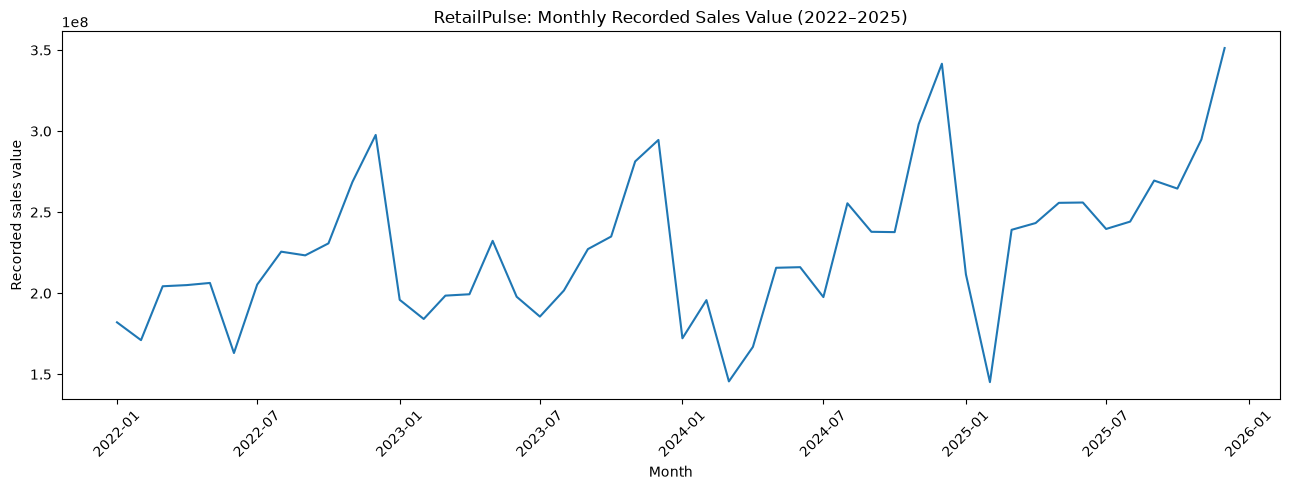

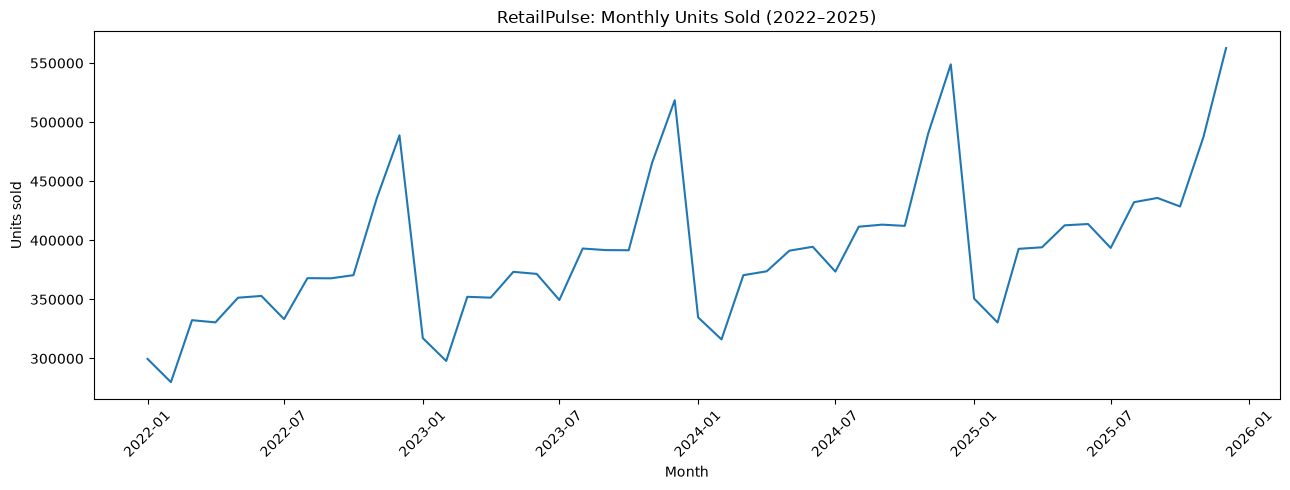

In [8]:

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

monthly = con.execute(f"""
    SELECT
        DATE_TRUNC('month', date)::DATE AS month,
        SUM(total_value) AS recorded_sales_value,
        SUM(quantity) AS units_sold
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

con.close()

# Chart 1: Monthly recorded sales value
plt.figure(figsize=(13, 5))
plt.plot(monthly["month"], monthly["recorded_sales_value"])
plt.title("RetailPulse: Monthly Recorded Sales Value (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Recorded sales value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: Monthly units sold
plt.figure(figsize=(13, 5))
plt.plot(monthly["month"], monthly["units_sold"])
plt.title("RetailPulse: Monthly Units Sold (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Units sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

quality = con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE quantity <= 0)
            AS nonpositive_quantity,
        COUNT(*) FILTER (WHERE unit_price < 0)
            AS negative_unit_price,
        COUNT(*) FILTER (WHERE total_value < 0)
            AS negative_total_value,
        COUNT(*) FILTER (
            WHERE discount_pct < 0 OR discount_pct > 1
        ) AS discount_outside_0_1,
        COUNT(*) FILTER (
            WHERE ABS(total_value - quantity * unit_price) > 0.02
        ) AS price_quantity_mismatches
    FROM read_csv_auto('{sales_path}', sample_size=10000)
""").fetchdf()

display(quality)
con.close()

,nonpositive_quantity,negative_unit_price,negative_total_value,discount_outside_0_1,price_quantity_mismatches
0,0,0,0,2090351,2090351


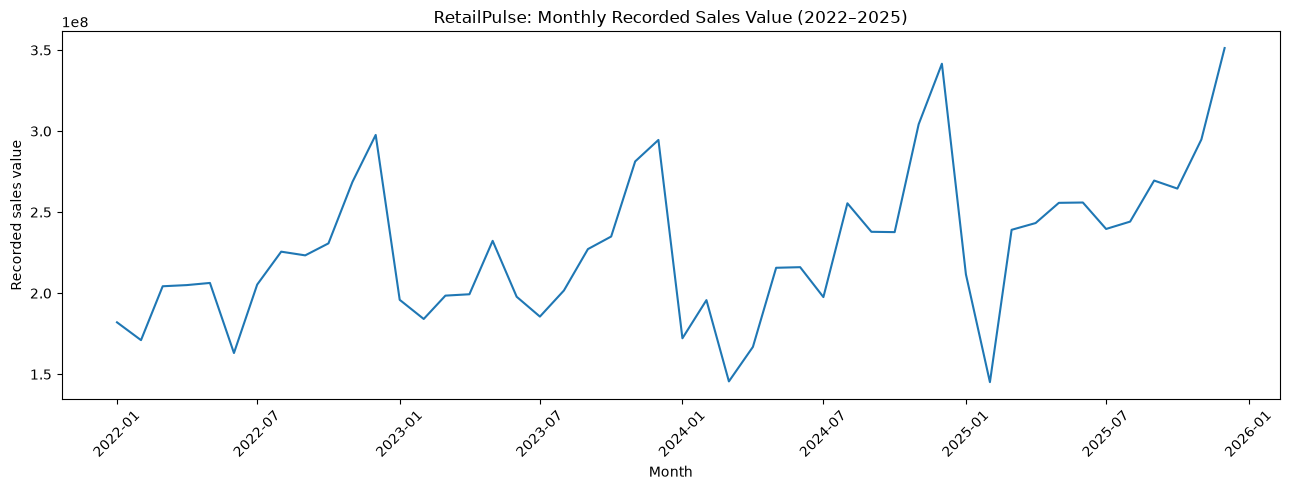

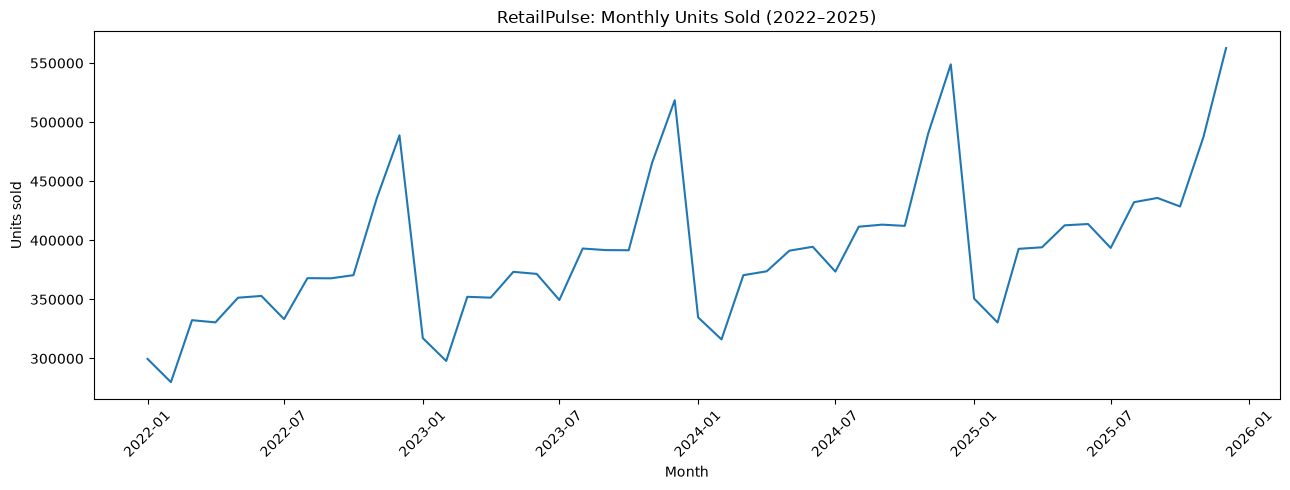

In [10]:

from pathlib import Path
import duckdb
import matplotlib.pyplot as plt

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

monthly = con.execute(f"""
    SELECT
        DATE_TRUNC('month', date)::DATE AS month,
        SUM(total_value) AS recorded_sales_value,
        SUM(quantity) AS units_sold
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY 1
    ORDER BY 1
""").fetchdf()

con.close()

# Chart 1: Monthly recorded sales value
plt.figure(figsize=(13, 5))
plt.plot(monthly["month"], monthly["recorded_sales_value"])
plt.title("RetailPulse: Monthly Recorded Sales Value (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Recorded sales value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Chart 2: Monthly units sold
plt.figure(figsize=(13, 5))
plt.plot(monthly["month"], monthly["units_sold"])
plt.title("RetailPulse: Monthly Units Sold (2022–2025)")
plt.xlabel("Month")
plt.ylabel("Units sold")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

quality = con.execute(f"""
    SELECT
        COUNT(*) FILTER (WHERE quantity <= 0)
            AS nonpositive_quantity,
        COUNT(*) FILTER (WHERE unit_price < 0)
            AS negative_unit_price,
        COUNT(*) FILTER (WHERE total_value < 0)
            AS negative_total_value,
        COUNT(*) FILTER (
            WHERE discount_pct < 0 OR discount_pct > 1
        ) AS discount_outside_0_1,
        COUNT(*) FILTER (
            WHERE ABS(total_value - quantity * unit_price) > 0.02
        ) AS price_quantity_mismatches
    FROM read_csv_auto('{sales_path}', sample_size=10000)
""").fetchdf()

display(quality)
con.close()

,nonpositive_quantity,negative_unit_price,negative_total_value,discount_outside_0_1,price_quantity_mismatches
0,0,0,0,2090351,2090351


In [12]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

diagnostics = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value - quantity * unit_price
            ) <= 0.02
        ) AS matches_before_discount,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price * (1 - discount_pct)
            ) <= 0.02
        ) AS matches_after_discount,

        COUNT(*) FILTER (
            WHERE discount_pct > 0
        ) AS rows_with_discount,

        ROUND(MIN(discount_pct), 4) AS min_discount,
        ROUND(AVG(discount_pct), 4) AS avg_discount,
        ROUND(MAX(discount_pct), 4) AS max_discount

    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
""").fetchdf()

display(diagnostics)
con.close()

,total_rows,matches_before_discount,matches_after_discount,rows_with_discount,min_discount,avg_discount,max_discount
0,9972038,7881687,7881687,2090351,0.0,6.2741,49.8


In [13]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

discount_check = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        MIN(discount_pct) AS min_discount,
        AVG(discount_pct) AS avg_discount,
        MAX(discount_pct) AS max_discount,

        COUNT(*) FILTER (
            WHERE discount_pct < 0 OR discount_pct > 1
        ) AS outside_0_to_1,

        COUNT(*) FILTER (
            WHERE discount_pct < 0 OR discount_pct > 100
        ) AS outside_0_to_100,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct / 100.0)
            ) <= 0.02
        ) AS matches_percent_formula,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct)
            ) <= 0.02
        ) AS matches_fraction_formula

    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
""").fetchdf()

display(discount_check)
con.close()

,total_rows,min_discount,avg_discount,max_discount,outside_0_to_1,outside_0_to_100,matches_percent_formula,matches_fraction_formula
0,9972038,0.0,6.274074,49.8,2090351,0,9972038,7881687


In [14]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

discounted_summary = con.execute(f"""
    SELECT
        COUNT(*) AS discounted_rows,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value - quantity * unit_price
            ) <= 0.02
        ) AS raw_formula_matches,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct / 100.0)
            ) <= 0.02
        ) AS percent_formula_matches,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct)
            ) <= 0.02
        ) AS fraction_formula_matches

    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    WHERE discount_pct > 0
""").fetchdf()

print("Discounted transaction summary:")
display(discounted_summary)

examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        sku_id,
        quantity,
        unit_price,
        discount_pct,
        total_value,
        ROUND(quantity * unit_price, 2) AS raw_calculation,
        ROUND(
            quantity * unit_price
            * (1 - discount_pct / 100.0), 2
        ) AS percent_discount_calculation
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    WHERE discount_pct > 0
    ORDER BY date
    LIMIT 10
""").fetchdf()

print("Sample discounted transactions:")
display(examples)

con.close()

Discounted transaction summary:


,discounted_rows,raw_formula_matches,percent_formula_matches,fraction_formula_matches
0,2090351,0,2090351,0


Sample discounted transactions:


,date,receipt_id,sku_id,quantity,unit_price,discount_pct,total_value,raw_calculation,percent_discount_calculation
0,2022-01-23,RCPT00062380,SKU01274,2,558.36,39.2,678.97,1116.72,678.97
1,2022-01-23,RCPT00077079,SKU03727,2,1660.93,39.2,2019.69,3321.86,2019.69
2,2022-01-23,RCPT00240461,SKU02705,1,3268.55,39.2,1987.28,3268.55,1987.28
3,2022-01-23,RCPT00252437,SKU03240,1,1042.33,39.2,633.74,1042.33,633.74
4,2022-01-23,RCPT00243771,SKU03426,1,1315.65,39.2,799.92,1315.65,799.92
5,2022-01-23,RCPT00416973,SKU03323,1,3001.52,39.2,1824.92,3001.52,1824.92
6,2022-01-23,RCPT00208483,SKU00921,1,3363.82,39.2,2045.20,3363.82,2045.20
7,2022-01-23,RCPT00036349,SKU03727,3,1660.93,39.2,3029.54,4982.79,3029.54
8,2022-01-23,RCPT00236163,SKU03727,5,1660.93,39.2,5049.23,8304.65,5049.23
9,2022-01-23,RCPT00424347,SKU02692,1,2095.03,39.2,1273.78,2095.03,1273.78


In [15]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

final_check = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct / 100.0)
            ) <= 0.02
        ) AS rows_matching_correct_formula,

        COUNT(*) FILTER (
            WHERE ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct / 100.0)
            ) > 0.02
        ) AS rows_still_mismatching,

        ROUND(
            MAX(ABS(
                total_value
                - quantity * unit_price
                    * (1 - discount_pct / 100.0)
            )),
            4
        ) AS maximum_absolute_difference

    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
""").fetchdf()

display(final_check)
con.close()

,total_rows,rows_matching_correct_formula,rows_still_mismatching,maximum_absolute_difference
0,9972038,9972038,0,0.005


In [16]:

import duckdb
from pathlib import Path

DATA_DIR = Path.home() / "Downloads" / "archive" / "retail_clean_dataset"
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

# Group rows that match across every transaction column.
con.execute(f"""
    CREATE OR REPLACE TEMP VIEW duplicate_groups AS
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    GROUP BY ALL
    HAVING COUNT(*) > 1
""")

# Summarize duplicate groups and excess copies.
duplicate_summary = con.execute("""
    SELECT
        COUNT(*) AS duplicate_groups,
        COALESCE(SUM(copies), 0) AS rows_in_duplicate_groups,
        COALESCE(SUM(copies - 1), 0) AS excess_duplicate_copies
    FROM duplicate_groups
""").fetchdf()

display(duplicate_summary)

# Inspect up to 10 examples.
duplicate_examples = con.execute("""
    SELECT *
    FROM duplicate_groups
    ORDER BY copies DESC
    LIMIT 10
""").fetchdf()

display(duplicate_examples)

con.close()

,duplicate_groups,rows_in_duplicate_groups,excess_duplicate_copies
0,12865,25884.0,13019.0


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id,copies
0,2025-07-08,RCPT04275460,ST19,SKU04321,CUST09159,1,961.30,961.30,In-Store,0.0,NaN,4
1,2025-06-14,RCPT02275248,ST22,SKU00254,CUST05384,1,105.55,105.55,Online,0.0,NaN,3
2,2022-02-25,RCPT00229929,ST12,SKU04321,CUST05346,1,961.30,961.30,In-Store,0.0,NaN,3
3,2024-11-09,RCPT05071671,ST01,SKU04321,CUST04650,1,961.30,961.30,In-Store,0.0,NaN,3
4,2024-01-24,RCPT02052360,ST06,SKU04321,CUST00042,2,961.30,995.91,In-Store,48.2,PROMO069,3
5,2022-07-17,RCPT04999586,ST05,SKU04321,CUST04828,1,961.30,961.30,In-Store,0.0,NaN,3
6,2025-09-25,RCPT04797242,ST18,SKU04321,CUST01568,1,961.30,961.30,In-Store,0.0,NaN,3
7,2022-10-27,RCPT01185116,ST04,SKU04321,CUST03021,1,961.30,961.30,Online,0.0,NaN,3
8,2025-11-10,RCPT04777924,ST12,SKU04321,CUST01593,1,961.30,961.30,In-Store,0.0,NaN,3
9,2023-06-12,RCPT04170860,ST23,SKU04321,CUST02235,1,961.30,961.30,Online,0.0,NaN,3


In [ ]:

from pathlib import Path

# Search common locations for existing dataset files
home = Path.home()
search_folders = [
    home / "Downloads",
    home / "Desktop",
    home / "Documents",
    home / "RetailPulse",
]

extensions = {".csv", ".xlsx", ".xls", ".parquet", ".zip"}

print("Searching for existing dataset files...\n")

found = []

for folder in search_folders:
    if not folder.exists():
        continue

    for path in folder.rglob("*"):
        try:
            if (
                path.is_file()
                and path.suffix.lower() in extensions
                and ".venv" not in path.parts
            ):
                found.append(path)
        except OSError:
            continue

if found:
    for path in found:
        size_mb = path.stat().st_size / (1024 * 1024)
        print(f"{path}  ({size_mb:.2f} MB)")
else:
    print("No dataset files found in the searched folders.")

Searching for existing dataset files...

/Users/venumudike/Downloads/BTC_Crypto_TimeSeries_Dashboard.pbix.zip  (0.53 MB)
/Users/venumudike/Downloads/sku_master.csv  (0.00 MB)
/Users/venumudike/Downloads/inventory_snapshots.csv  (0.20 MB)
/Users/venumudike/Downloads/STOCK ANALYSIS DASHBOARD.pbix.zip  (1.73 MB)
/Users/venumudike/Downloads/ilovepdf_pages-to-jpg.zip  (0.41 MB)
/Users/venumudike/Downloads/.bin.zip  (0.11 MB)
/Users/venumudike/Downloads/sales_daily.csv  (1.38 MB)
/Users/venumudike/Downloads/calendar.csv  (0.04 MB)
/Users/venumudike/Downloads/online_retail_II.xlsx  (43.51 MB)
/Users/venumudike/Downloads/8 c.zip  (181.62 MB)
/Users/venumudike/Downloads/retailpulse-analytics.zip  (8.06 MB)
/Users/venumudike/Downloads/RetailPulse_Cleaned_Dataset.csv  (0.72 MB)
/Users/venumudike/Downloads/archive.zip  (2087.96 MB)
/Users/venumudike/Downloads/archive/retail_clean_dataset/sales_transactions.csv.zip  (173.53 MB)
/Users/venumudike/Downloads/archive/retail_clean_dataset/customer_maste

In [17]:

import duckdb
from pathlib import Path

DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

con.execute(f"""
    CREATE OR REPLACE TEMP VIEW duplicate_groups AS
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    GROUP BY ALL
    HAVING COUNT(*) > 1
""")

# Table 1: Duplicate summary
duplicate_summary = con.execute("""
    SELECT
        COUNT(*) AS duplicate_groups,
        COALESCE(SUM(copies), 0) AS rows_in_duplicate_groups,
        COALESCE(SUM(copies - 1), 0) AS excess_duplicate_copies
    FROM duplicate_groups
""").fetchdf()

display(duplicate_summary)

# Table 2: Examples of duplicate records
duplicate_examples = con.execute("""
    SELECT *
    FROM duplicate_groups
    ORDER BY copies DESC
    LIMIT 10
""").fetchdf()

display(duplicate_examples)

con.close()

,duplicate_groups,rows_in_duplicate_groups,excess_duplicate_copies
0,12865,25884.0,13019.0


,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id,copies
0,2025-07-08,RCPT04275460,ST19,SKU04321,CUST09159,1,961.3,961.30,In-Store,0.0,NaN,4
1,2023-12-27,RCPT03666367,ST04,SKU04321,CUST04499,1,961.3,673.87,In-Store,29.9,PROMO043,3
2,2025-06-22,RCPT02147018,ST17,SKU04321,CUST09832,1,961.3,961.30,In-Store,0.0,NaN,3
3,2024-10-18,RCPT02542522,ST14,SKU04321,CUST07157,2,961.3,1922.60,Online,0.0,NaN,3
4,2025-11-23,RCPT00060202,ST23,SKU04321,CUST08593,1,961.3,961.30,Online,0.0,NaN,3
5,2023-10-24,RCPT01699293,ST01,SKU04321,CUST02892,1,961.3,961.30,Online,0.0,NaN,3
6,2023-01-04,RCPT00300020,ST23,SKU04321,CUST09228,1,961.3,961.30,Online,0.0,NaN,3
7,2024-10-07,RCPT03591147,ST12,SKU04321,CUST08998,1,961.3,701.75,In-Store,27.0,PROMO094,3
8,2025-05-27,RCPT00820212,ST18,SKU04321,CUST07818,1,961.3,961.30,In-Store,0.0,NaN,3
9,2023-06-12,RCPT04170860,ST23,SKU04321,CUST02235,1,961.3,961.30,Online,0.0,NaN,3


In [18]:

import duckdb
from pathlib import Path

DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

receipt_check = con.execute(f"""
    WITH receipt_counts AS (
        SELECT
            receipt_id,
            COUNT(*) AS line_count,
            COUNT(DISTINCT sku_id) AS distinct_skus
        FROM read_csv_auto(
            '{sales_path}',
            sample_size=10000
        )
        GROUP BY receipt_id
    )
    SELECT
        COUNT(*) AS total_receipts,
        COUNT(*) FILTER (
            WHERE line_count > 1
        ) AS receipts_with_multiple_lines,
        COUNT(*) FILTER (
            WHERE distinct_skus > 1
        ) AS receipts_with_multiple_skus
    FROM receipt_counts
""").fetchdf()

display(receipt_check)

con.close()

,total_receipts,receipts_with_multiple_lines,receipts_with_multiple_skus
0,5174631,2840149,2832103


In [19]:

import duckdb
from pathlib import Path

DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

# Overall transaction metrics
overall_summary = con.execute(f"""
    SELECT
        COUNT(*) AS transaction_lines,
        ROUND(AVG(quantity), 2) AS avg_quantity_per_line,
        ROUND(AVG(total_value), 2) AS avg_recorded_line_value,
        ROUND(SUM(quantity), 0) AS total_units_sold,
        ROUND(SUM(total_value), 2) AS total_recorded_sales_value
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
""").fetchdf()

print("Overall sales summary")
display(overall_summary)

# Compare sales channels
channel_summary = con.execute(f"""
    SELECT
        channel,
        COUNT(*) AS transaction_lines,
        COUNT(DISTINCT receipt_id) AS distinct_receipts,
        ROUND(SUM(quantity), 0) AS units_sold,
        ROUND(SUM(total_value), 2) AS recorded_sales_value
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    GROUP BY channel
    ORDER BY recorded_sales_value DESC
""").fetchdf()

print("Sales by channel")
display(channel_summary)

con.close()

Overall sales summary


,transaction_lines,avg_quantity_per_line,avg_recorded_line_value,total_units_sold,total_recorded_sales_value
0,9972038,1.88,1094.84,18750830.0,1.091774e+10


Sales by channel


,channel,transaction_lines,distinct_receipts,units_sold,recorded_sales_value
0,In-Store,5511403,2860654,10365551.0,6.032996e+09
1,Online,2966045,1538090,5574769.0,3.246584e+09
2,Mobile App,1494590,775887,2810510.0,1.638158e+09


In [20]:
Overall sales summary
transaction_lines	avg_quantity_per_line	avg_recorded_line_value	total_units_sold	total_recorded_sales_value
0	9972038	1.88	1094.84	18750830.0	1.091774e+10
Sales by channel
channel	transaction_lines	distinct_receipts	units_sold	recorded_sales_value
0	In-Store	5511403	2860654	10365551.0	6.032996e+09
1	Online	2966045	1538090	5574769.0	3.246584e+09
2	Mobile App	1494590	775887	2810510.0	1.638158e+09


SyntaxError: invalid syntax (492835969.py, line 1)

In [21]:

from pathlib import Path
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

monthly = con.execute(f"""
    SELECT
        YEAR(date) AS year,
        MONTH(date) AS month,
        SUM(total_value) AS recorded_sales_value,
        SUM(quantity) AS units_sold
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    GROUP BY YEAR(date), MONTH(date)
    ORDER BY year, month
""").fetchdf()

con.close()

# Display the first 12 monthly records
display(monthly.head(12))

,year,month,recorded_sales_value,units_sold
0,2022,1,1.820395e+08,299649.0
1,2022,2,1.710435e+08,279983.0
2,2022,3,2.042833e+08,332417.0
3,2022,4,2.050013e+08,330560.0
4,2022,5,2.063285e+08,351452.0
5,2022,6,1.630977e+08,352922.0
6,2022,7,2.053246e+08,333342.0
7,2022,8,2.256207e+08,367973.0
8,2022,9,2.233422e+08,367848.0
9,2022,10,2.307381e+08,370513.0


In [22]:

# Average sales and units for each calendar month
seasonality = (
    monthly.groupby("month")
    .agg(
        avg_monthly_sales=("recorded_sales_value", "mean"),
        avg_monthly_units=("units_sold", "mean")
    )
    .reset_index()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

seasonality["month_name"] = seasonality["month"].map(
    lambda m: month_names[int(m) - 1]
)

display(
    seasonality[
        ["month_name", "avg_monthly_sales", "avg_monthly_units"]
    ].round(2)
)

,month_name,avg_monthly_sales,avg_monthly_units
0,Jan,1.904470e+08,325573.75
1,Feb,1.740052e+08,306125.00
2,Mar,1.968712e+08,361980.00
3,Apr,2.036277e+08,362483.50
4,May,2.275173e+08,382180.00
5,Jun,2.082284e+08,383210.25
6,Jul,2.070359e+08,362485.00
7,Aug,2.317320e+08,401206.75
8,Sep,2.394838e+08,402172.00
9,Oct,2.419807e+08,400743.25


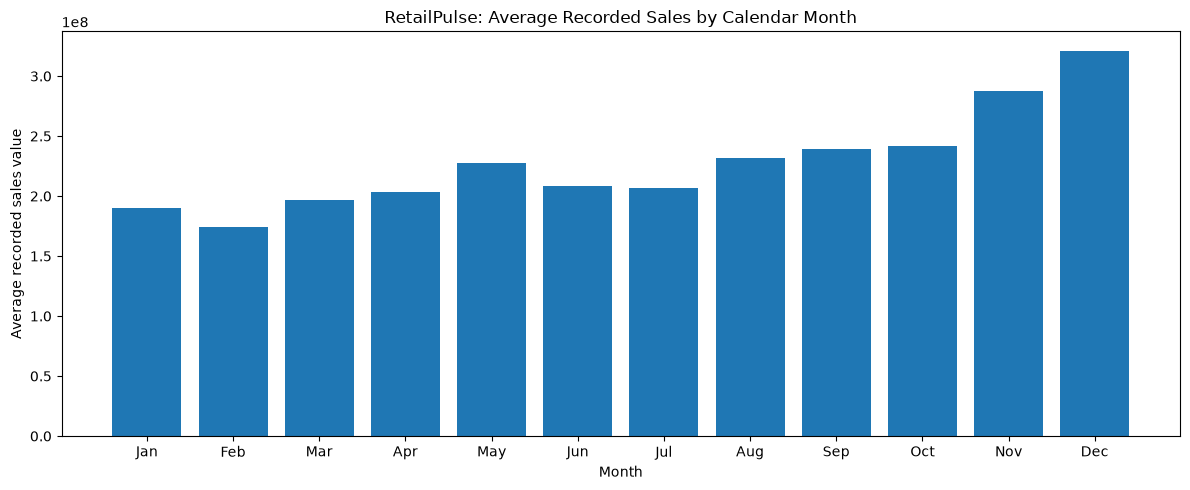

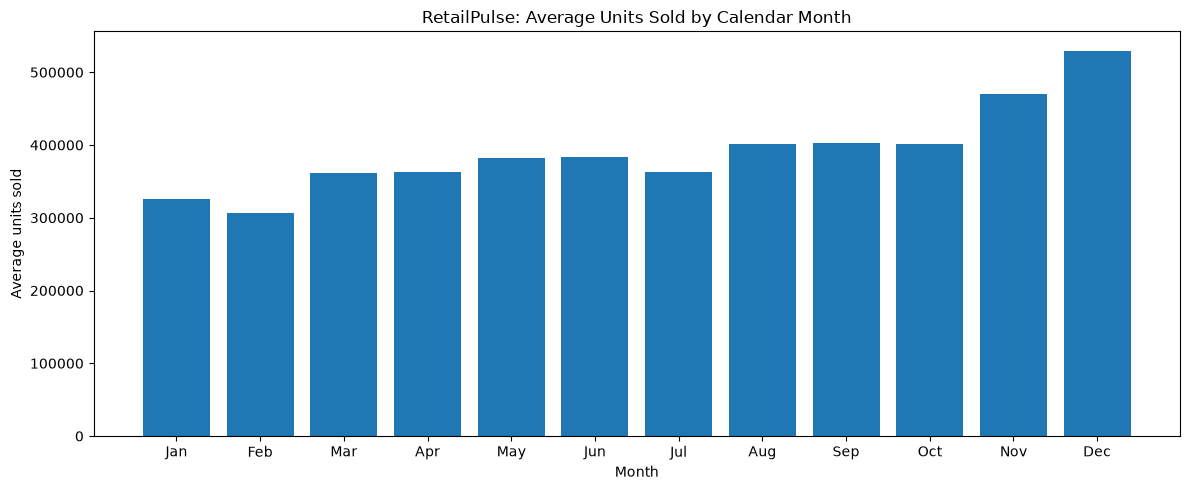

In [23]:

plt.figure(figsize=(12, 5))
plt.bar(
    seasonality["month_name"],
    seasonality["avg_monthly_sales"]
)
plt.title("RetailPulse: Average Recorded Sales by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average recorded sales value")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(
    seasonality["month_name"],
    seasonality["avg_monthly_units"]
)
plt.title("RetailPulse: Average Units Sold by Calendar Month")
plt.xlabel("Month")
plt.ylabel("Average units sold")
plt.tight_layout()
plt.show()

In [24]:

# Use the monthly DataFrame created in your previous cell.

monthly["year_avg_sales"] = (
    monthly.groupby("year")["recorded_sales_value"]
    .transform("mean")
)

monthly["sales_seasonal_index"] = (
    monthly["recorded_sales_value"]
    / monthly["year_avg_sales"]
    * 100
)

monthly["year_avg_units"] = (
    monthly.groupby("year")["units_sold"]
    .transform("mean")
)

monthly["units_seasonal_index"] = (
    monthly["units_sold"]
    / monthly["year_avg_units"]
    * 100
)

# Average normalized index for each calendar month
seasonal_index = (
    monthly.groupby("month")
    .agg(
        sales_index=("sales_seasonal_index", "mean"),
        units_index=("units_seasonal_index", "mean")
    )
    .reset_index()
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

seasonal_index["month_name"] = seasonal_index["month"].map(
    lambda m: month_names[int(m) - 1]
)

display(
    seasonal_index[
        ["month_name", "sales_index", "units_index"]
    ].round(1)
)

,month_name,sales_index,units_index
0,Jan,83.8,83.3
1,Feb,77.1,78.3
2,Mar,86.4,92.6
3,Apr,89.4,92.8
4,May,100.0,97.8
5,Jun,91.1,98.1
6,Jul,90.9,92.8
7,Aug,102.0,102.7
8,Sep,105.2,102.9
9,Oct,106.4,102.6


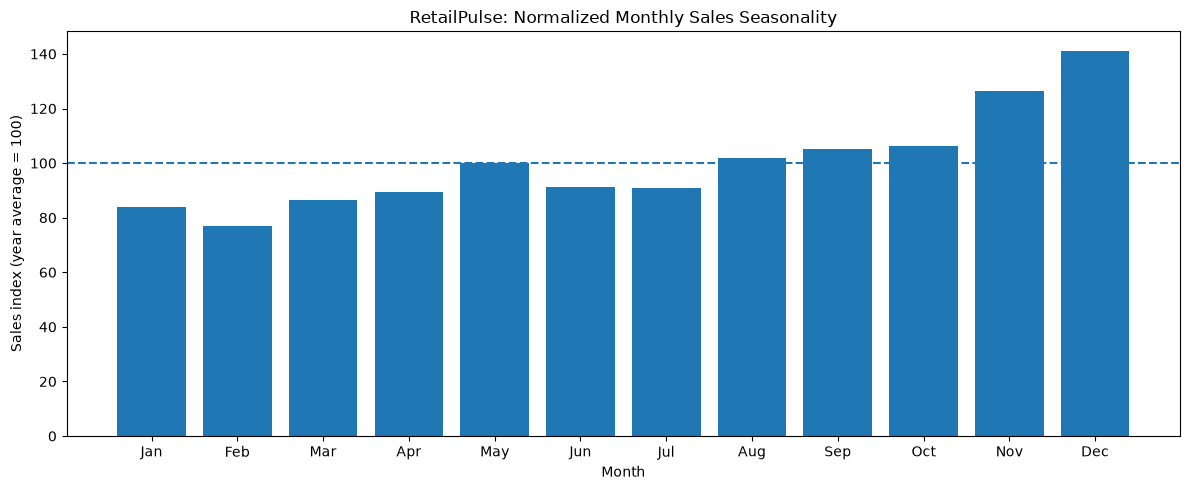

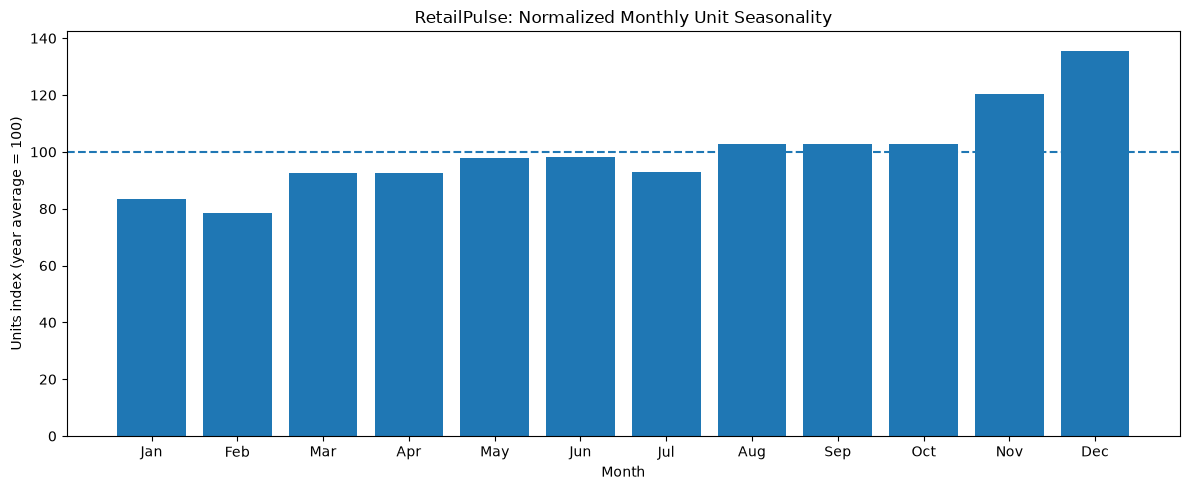

In [25]:

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.bar(
    seasonal_index["month_name"],
    seasonal_index["sales_index"]
)
plt.axhline(100, linestyle="--")
plt.title("RetailPulse: Normalized Monthly Sales Seasonality")
plt.xlabel("Month")
plt.ylabel("Sales index (year average = 100)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(
    seasonal_index["month_name"],
    seasonal_index["units_index"]
)
plt.axhline(100, linestyle="--")
plt.title("RetailPulse: Normalized Monthly Unit Seasonality")
plt.xlabel("Month")
plt.ylabel("Units index (year average = 100)")
plt.tight_layout()
plt.show()

In [26]:

# Use the existing monthly DataFrame from the previous cells.

monthly_detail = monthly.copy()

monthly_detail["year_avg_sales"] = (
    monthly_detail.groupby("year")["recorded_sales_value"]
    .transform("mean")
)

monthly_detail["sales_index"] = (
    monthly_detail["recorded_sales_value"]
    / monthly_detail["year_avg_sales"] * 100
)

monthly_detail["year_avg_units"] = (
    monthly_detail.groupby("year")["units_sold"]
    .transform("mean")
)

monthly_detail["units_index"] = (
    monthly_detail["units_sold"]
    / monthly_detail["year_avg_units"] * 100
)

month_names = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

monthly_detail["month_name"] = monthly_detail["month"].map(
    lambda m: month_names[int(m) - 1]
)

# Compare sales indices across years
sales_pivot = monthly_detail.pivot(
    index="month_name",
    columns="year",
    values="sales_index"
).reindex(month_names)

display(sales_pivot.round(1))

# Compare units indices across years
units_pivot = monthly_detail.pivot(
    index="month_name",
    columns="year",
    values="units_index"
).reindex(month_names)

display(units_pivot.round(1))

year,2022,2023,2024,2025
month_name,,,,
Jan,84.6,89.3,76.9,84.2
Feb,79.5,83.9,87.4,57.8
Mar,94.9,90.5,65.0,95.2
Apr,95.2,90.8,74.5,96.8
May,95.9,105.9,96.3,101.8
Jun,75.8,90.1,96.5,101.9
Jul,95.4,84.6,88.3,95.4
Aug,104.8,91.9,114.1,97.2
Sep,103.8,103.5,106.3,107.3


year,2022,2023,2024,2025
month_name,,,,
Jan,83.4,83.2,83.2,83.6
Feb,77.9,78.2,78.5,78.8
Mar,92.5,92.4,92.0,93.6
Apr,92.0,92.2,92.9,93.9
May,97.8,97.9,97.2,98.4
Jun,98.2,97.5,98.0,98.6
Jul,92.8,91.7,92.8,93.8
Aug,102.4,103.1,102.2,103.0
Sep,102.4,102.8,102.7,103.9


In [27]:

import duckdb
from pathlib import Path
import matplotlib.pyplot as plt

DATA_DIR = (
    Path.home()
    / "Downloads"
    / "archive"
    / "retail_clean_dataset"
)
sales_path = str(DATA_DIR / "sales_transactions.csv").replace("'", "''")

con = duckdb.connect()

daily = con.execute(f"""
    SELECT
        date,
        SUM(quantity) AS units_sold,
        SUM(total_value) AS recorded_sales_value,
        COUNT(*) AS transaction_lines
    FROM read_csv_auto(
        '{sales_path}',
        sample_size=10000
    )
    GROUP BY date
    ORDER BY date
""").fetchdf()

con.close()

daily["date"] = pd.to_datetime(daily["date"])

print("Daily dataset shape:", daily.shape)
print("First date:", daily["date"].min())
print("Last date:", daily["date"].max())
print("Missing dates:", (
    daily["date"].max() - daily["date"].min()
).days + 1 - daily["date"].nunique())

display(daily.head())

Daily dataset shape: (1461, 4)
First date: 2022-01-01 00:00:00
Last date: 2025-12-31 00:00:00
Missing dates: 0


,date,units_sold,recorded_sales_value,transaction_lines
0,2022-01-01,9539.0,5803048.93,5077
1,2022-01-02,9645.0,5933508.44,5137
2,2022-01-03,9696.0,6041608.01,5172
3,2022-01-04,9755.0,5847850.64,5124
4,2022-01-05,9322.0,5832333.56,4972


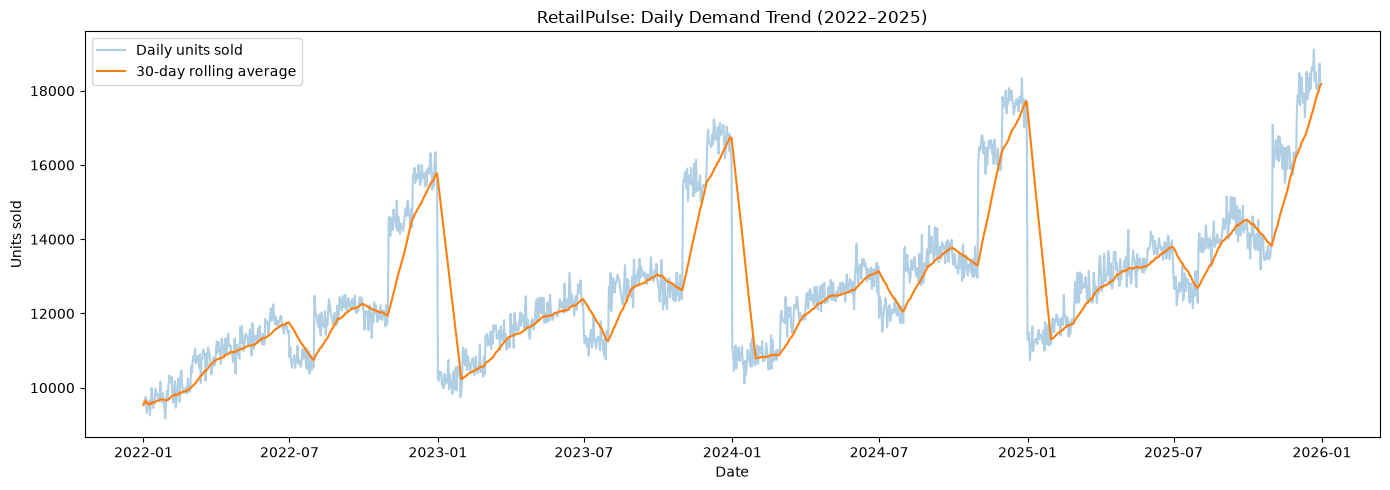

In [28]:

daily["units_30day_avg"] = (
    daily["units_sold"]
    .rolling(window=30, min_periods=1)
    .mean()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily["date"],
    daily["units_sold"],
    alpha=0.35,
    label="Daily units sold"
)

plt.plot(
    daily["date"],
    daily["units_30day_avg"],
    label="30-day rolling average"
)

plt.title("RetailPulse: Daily Demand Trend (2022–2025)")
plt.xlabel("Date")
plt.ylabel("Units sold")
plt.legend()
plt.tight_layout()
plt.show()

In [29]:

import pandas as pd

# Use the daily DataFrame created in your previous cell.
daily = daily.sort_values("date").reset_index(drop=True)

expected_dates = pd.date_range(
    start=daily["date"].min(),
    end=daily["date"].max(),
    freq="D"
)

missing_dates = expected_dates.difference(
    pd.DatetimeIndex(daily["date"])
)

print("Daily observations:", len(daily))
print("First date:", daily["date"].min().date())
print("Last date:", daily["date"].max().date())
print("Missing calendar dates:", len(missing_dates))
print("Duplicate dates in daily data:", daily["date"].duplicated().sum())

if len(missing_dates) > 0:
    print("First missing dates:", list(missing_dates[:10]))

Daily observations: 1461
First date: 2022-01-01
Last date: 2025-12-31
Missing calendar dates: 0
Duplicate dates in daily data: 0


In [30]:

import pandas as pd

# Ensure the daily series is ordered by date.
daily = daily.sort_values("date").reset_index(drop=True)

# Reserve October–December 2025 for testing.
test_start = pd.Timestamp("2025-10-01")

train = daily[daily["date"] < test_start].copy()
test = daily[daily["date"] >= test_start].copy()

print("Training period:")
print(train["date"].min().date(), "to", train["date"].max().date())
print("Training observations:", len(train))

print("\nTesting period:")
print(test["date"].min().date(), "to", test["date"].max().date())
print("Testing observations:", len(test))

print("\nExpected test observations: 92")
print("Actual test observations:", len(test))

Training period:
2022-01-01 to 2025-09-30
Training observations: 1369

Testing period:
2025-10-01 to 2025-12-31
Testing observations: 92

Expected test observations: 92
Actual test observations: 92


In [31]:

import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Use the existing daily, train, and test DataFrames.
daily = daily.sort_values("date").reset_index(drop=True)

# Historical demand lookup.
units_by_date = daily.set_index("date")["units_sold"]

# Predict each test date using the same date one year earlier.
test = test.copy()

test["baseline_forecast"] = test["date"].map(
    lambda d: units_by_date.get(
        d - pd.DateOffset(years=1),
        np.nan
    )
)

# Verify that every test date received a forecast.
print("Test observations:", len(test))
print("Missing baseline forecasts:", test["baseline_forecast"].isna().sum())

# Evaluate the baseline.
actual = test["units_sold"]
predicted = test["baseline_forecast"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = (
    np.abs((actual - predicted) / actual).mean() * 100
)

print(f"\nBaseline MAE:  {mae:.2f} units")
print(f"Baseline RMSE: {rmse:.2f} units")
print(f"Baseline MAPE: {mape:.2f}%")

display(
    test[["date", "units_sold", "baseline_forecast"]].head(10)
)

Test observations: 92
Missing baseline forecasts: 0

Baseline MAE:  516.16 units
Baseline RMSE: 625.23 units
Baseline MAPE: 3.24%


,date,units_sold,baseline_forecast
1369,2025-10-01,13770.0,13311.0
1370,2025-10-02,13758.0,13612.0
1371,2025-10-03,14169.0,13576.0
1372,2025-10-04,13481.0,13227.0
1373,2025-10-05,14057.0,13242.0
1374,2025-10-06,14093.0,13283.0
1375,2025-10-07,14615.0,13072.0
1376,2025-10-08,14330.0,13643.0
1377,2025-10-09,13810.0,13238.0
1378,2025-10-10,13717.0,13532.0


In [32]:
print("Test observations:", len(test))
print("Missing baseline forecasts:", test["baseline_forecast"].isna().sum())

actual = test["units_sold"]
predicted = test["baseline_forecast"]

mae = mean_absolute_error(actual, predicted)
rmse = np.sqrt(mean_squared_error(actual, predicted))
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"Baseline MAE:  {mae:.2f} units")
print(f"Baseline RMSE: {rmse:.2f} units")
print(f"Baseline MAPE: {mape:.2f}%")

Test observations: 92
Missing baseline forecasts: 0
Baseline MAE:  516.16 units
Baseline RMSE: 625.23 units
Baseline MAPE: 3.24%


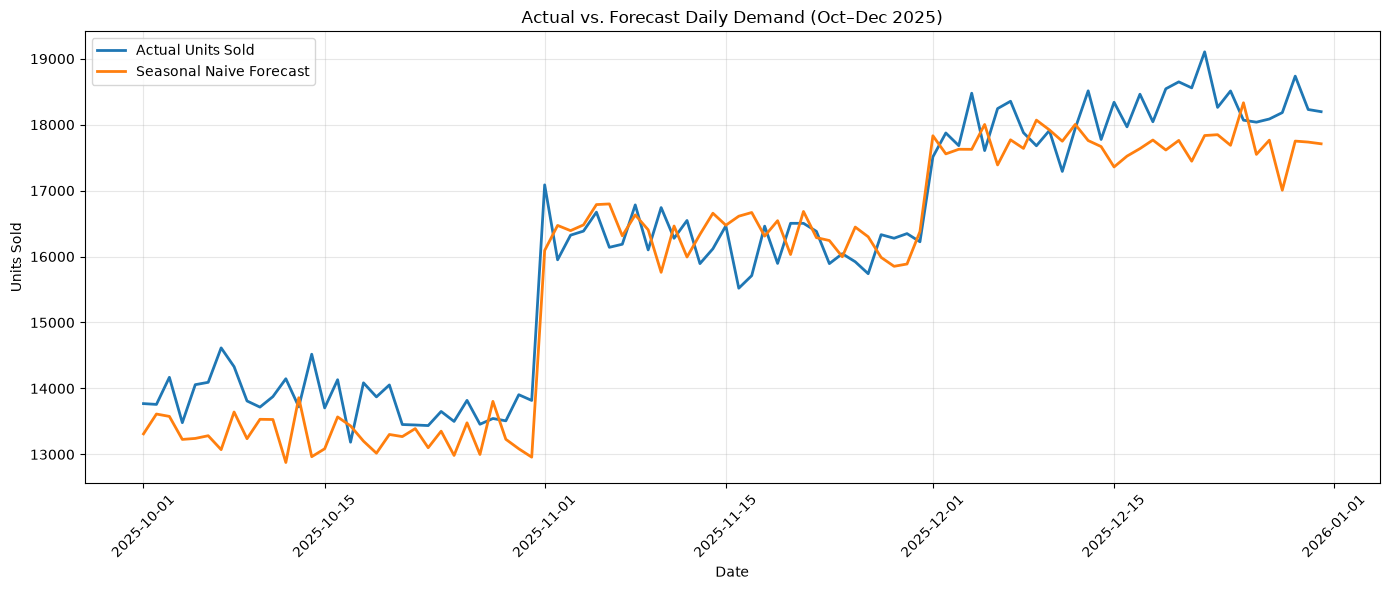

In [33]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    test["date"],
    test["units_sold"],
    label="Actual Units Sold",
    linewidth=2
)

plt.plot(
    test["date"],
    test["baseline_forecast"],
    label="Seasonal Naive Forecast",
    linewidth=2
)

plt.title("Actual vs. Forecast Daily Demand (Oct–Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [34]:

duplicate_examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 15
""").fetchdf()

display(duplicate_examples)

ConnectionException: Connection Error: Connection already closed!

In [35]:

duplicate_examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 15
""").fetchdf()

display(duplicate_examples)

ConnectionException: Connection Error: Connection already closed!


duplicate_examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 15
""").fetchdf()

display(duplicate_examples)

In [36]:

duplicate_examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 15
""").fetchdf()

display(duplicate_examples)

ConnectionException: Connection Error: Connection already closed!

In [37]:
import duckdb

con = duckdb.connect()

print("DuckDB connection reopened successfully!")
print(con.execute("SELECT 1").fetchone())

DuckDB connection reopened successfully!
(1,)


In [38]:
sales_path = (
    "/Users/venumudike/Downloads/archive/"
    "retail_clean_dataset/sales_transactions.csv"
)

In [39]:

duplicate_examples = con.execute(f"""
    SELECT
        date,
        receipt_id,
        store_id,
        sku_id,
        customer_id,
        quantity,
        unit_price,
        total_value,
        channel,
        discount_pct,
        promo_id,
        COUNT(*) AS copies
    FROM read_csv_auto('{sales_path}', sample_size=10000)
    GROUP BY ALL
    HAVING COUNT(*) > 1
    ORDER BY copies DESC
    LIMIT 15
""").fetchdf()

display(duplicate_examples)

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id,copies
0,2025-07-08,RCPT04275460,ST19,SKU04321,CUST09159,1,961.3,961.30,In-Store,0.0,NaN,4
1,2024-11-16,RCPT05126841,ST26,SKU04321,CUST06593,2,961.3,1922.60,Online,0.0,NaN,3
2,2024-10-29,RCPT00241925,ST29,SKU04321,CUST09487,2,961.3,1922.60,In-Store,0.0,NaN,3
3,2023-07-15,RCPT05143274,ST06,SKU04321,CUST07565,1,961.3,961.30,Mobile App,0.0,NaN,3
4,2025-09-10,RCPT02061620,ST22,SKU04321,CUST00211,1,961.3,961.30,In-Store,0.0,NaN,3
5,2022-04-12,RCPT03288615,ST24,SKU04321,CUST02875,2,961.3,1922.60,In-Store,0.0,NaN,3
6,2025-07-30,RCPT03101429,ST14,SKU04321,CUST06844,2,961.3,993.98,In-Store,48.3,PROMO032,3
7,2024-05-10,RCPT03635983,ST29,SKU04321,CUST00168,1,961.3,645.99,In-Store,32.8,PROMO036,3
8,2025-08-08,RCPT01807375,ST18,SKU04321,CUST06671,1,961.3,496.99,In-Store,48.3,PROMO032,3
9,2023-01-25,RCPT03729768,ST14,SKU04321,CUST05931,2,961.3,1922.60,Online,0.0,NaN,3


In [40]:

duplicate_impact = con.execute(f"""
    WITH grouped AS (
        SELECT
            date,
            receipt_id,
            store_id,
            sku_id,
            customer_id,
            quantity,
            unit_price,
            total_value,
            channel,
            discount_pct,
            promo_id,
            COUNT(*) AS copies
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        GROUP BY ALL
    )
    SELECT
        SUM(copies) AS original_rows,
        COUNT(*) AS distinct_rows,
        SUM(copies - 1) AS excess_duplicate_rows,

        SUM(quantity * copies) AS original_units,
        SUM(quantity) AS units_after_exact_deduplication,
        SUM(quantity * (copies - 1)) AS excess_units,

        ROUND(SUM(total_value * copies), 2) AS original_sales_value,
        ROUND(SUM(total_value), 2) AS sales_value_after_exact_deduplication,
        ROUND(SUM(total_value * (copies - 1)), 2)
            AS excess_recorded_sales_value
    FROM grouped
""").fetchdf()

display(duplicate_impact.T)

,0
original_rows,9.972038e+06
distinct_rows,9.959019e+06
excess_duplicate_rows,1.301900e+04
original_units,1.875083e+07
units_after_exact_deduplication,1.873300e+07
excess_units,1.782500e+04
original_sales_value,1.091774e+10
sales_value_after_exact_deduplication,1.090291e+10
excess_recorded_sales_value,1.482821e+07


In [41]:

# Build daily demand after removing exact duplicate rows.
# The original CSV remains unchanged.

daily_clean = con.execute(f"""
    SELECT
        date,
        SUM(quantity) AS units_sold,
        SUM(total_value) AS recorded_sales_value,
        COUNT(*) AS transaction_lines
    FROM (
        SELECT DISTINCT *
        FROM read_csv_auto('{sales_path}', sample_size=10000)
    ) AS deduplicated
    GROUP BY date
    ORDER BY date
""").fetchdf()

daily_clean["date"] = pd.to_datetime(daily_clean["date"])

print("Daily observations:", len(daily_clean))
print("First date:", daily_clean["date"].min())
print("Last date:", daily_clean["date"].max())
print("Total units:", daily_clean["units_sold"].sum())
print(
    "Total recorded sales value:",
    round(daily_clean["recorded_sales_value"].sum(), 2)
)

display(daily_clean.head())

Daily observations: 1461
First date: 2022-01-01 00:00:00
Last date: 2025-12-31 00:00:00
Total units: 18733005.0
Total recorded sales value: 10902909080.73


,date,units_sold,recorded_sales_value,transaction_lines
0,2022-01-01,9529.0,5796378.22,5068
1,2022-01-02,9637.0,5926177.21,5132
2,2022-01-03,9679.0,6028251.58,5163
3,2022-01-04,9749.0,5844144.77,5120
4,2022-01-05,9320.0,5830410.96,4970


In [42]:

import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Sort the deduplicated daily data
daily_clean = daily_clean.sort_values("date").reset_index(drop=True)

# Use Jan 2022–Sep 2025 for training and Oct–Dec 2025 for testing
test_start = pd.Timestamp("2025-10-01")

train_clean = daily_clean[daily_clean["date"] < test_start].copy()
test_clean = daily_clean[daily_clean["date"] >= test_start].copy()

# Seasonal-naive forecast: use the same calendar date from the previous year
clean_units_by_date = daily_clean.set_index("date")["units_sold"]

test_clean["baseline_forecast"] = test_clean["date"].map(
    lambda d: clean_units_by_date.get(
        d - pd.DateOffset(years=1), np.nan
    )
)

# Check forecast coverage
print("Training observations:", len(train_clean))
print("Test observations:", len(test_clean))
print(
    "Missing forecasts:",
    test_clean["baseline_forecast"].isna().sum()
)

# Calculate evaluation metrics
actual = test_clean["units_sold"]
predicted = test_clean["baseline_forecast"]

mae_clean = mean_absolute_error(actual, predicted)
rmse_clean = np.sqrt(mean_squared_error(actual, predicted))
mape_clean = np.mean(np.abs((actual - predicted) / actual)) * 100

print("\nCLEANED DATA BASELINE RESULTS")
print(f"MAE:  {mae_clean:.2f} units")
print(f"RMSE: {rmse_clean:.2f} units")
print(f"MAPE: {mape_clean:.2f}%")

display(
    test_clean[
        ["date", "units_sold", "baseline_forecast"]
    ].head(10)
)

Training observations: 1369
Test observations: 92
Missing forecasts: 0

CLEANED DATA BASELINE RESULTS
MAE:  515.37 units
RMSE: 623.17 units
MAPE: 3.24%


,date,units_sold,baseline_forecast
1369,2025-10-01,13753.0,13298.0
1370,2025-10-02,13736.0,13604.0
1371,2025-10-03,14152.0,13561.0
1372,2025-10-04,13460.0,13213.0
1373,2025-10-05,14038.0,13228.0
1374,2025-10-06,14081.0,13278.0
1375,2025-10-07,14594.0,13062.0
1376,2025-10-08,14317.0,13629.0
1377,2025-10-09,13802.0,13219.0
1378,2025-10-10,13703.0,13521.0


In [43]:

try:
    import prophet
    print("Prophet is installed.")
    print("Version:", prophet.__version__)
except ImportError:
    print("Prophet is not installed yet.")

Prophet is not installed yet.


In [44]:
%pip install prophet


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 886.1 kB/s  0:00:13 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 1.1 MB/s  0:00:01 eta 0:00:010m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [prophet]m4/5 [prophet]]
Note: you may need to restart the kernel to use updated packages.


In [45]:
import prophet

print("Prophet installed successfully!")
print("Version:", prophet.__version__)

Importing plotly failed. Interactive plots will not work.


Prophet installed successfully!
Version: 1.4.0


In [46]:

# Prepare daily demand data for Prophet
prophet_data = daily_clean[["date", "units_sold"]].copy()

prophet_data = prophet_data.rename(
    columns={
        "date": "ds",
        "units_sold": "y"
    }
)

prophet_data = prophet_data.sort_values("ds").reset_index(drop=True)

# Use the same chronological training and test periods
train_prophet = prophet_data[
    prophet_data["ds"] < "2025-10-01"
].copy()

test_prophet = prophet_data[
    prophet_data["ds"] >= "2025-10-01"
].copy()

print("Training rows:", len(train_prophet))
print("Test rows:", len(test_prophet))
print("Missing values:", prophet_data[["ds", "y"]].isna().sum().sum())

display(train_prophet.head())
display(test_prophet.head())

Training rows: 1369
Test rows: 92
Missing values: 0


,ds,y
0,2022-01-01,9529.0
1,2022-01-02,9637.0
2,2022-01-03,9679.0
3,2022-01-04,9749.0
4,2022-01-05,9320.0


,ds,y
1369,2025-10-01,13753.0
1370,2025-10-02,13736.0
1371,2025-10-03,14152.0
1372,2025-10-04,13460.0
1373,2025-10-05,14038.0


In [47]:

from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Initialize Prophet with yearly and weekly seasonality
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train using data before October 2025
model.fit(train_prophet)

# Forecast the test period
future = test_prophet[["ds"]].copy()
forecast = model.predict(future)

# Combine actual demand with predicted demand
prophet_results = test_prophet.merge(
    forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

# Evaluate predictions
actual = prophet_results["y"]
predicted = prophet_results["yhat"]

mae_prophet = mean_absolute_error(actual, predicted)
rmse_prophet = np.sqrt(mean_squared_error(actual, predicted))
mape_prophet = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("PROPHET FORECAST RESULTS")
print(f"MAE:  {mae_prophet:.2f} units")
print(f"RMSE: {rmse_prophet:.2f} units")
print(f"MAPE: {mape_prophet:.2f}%")

display(prophet_results.head(10))


21:28:47 - cmdstanpy - INFO - Chain [1] start processing
21:28:49 - cmdstanpy - INFO - Chain [1] done processing


PROPHET FORECAST RESULTS
MAE:  702.47 units
RMSE: 920.48 units
MAPE: 4.35%


,ds,y,yhat,yhat_lower,yhat_upper
0,2025-10-01,13753.0,14332.785781,13630.453955,14984.240893
1,2025-10-02,13736.0,14280.526309,13630.412105,14949.421686
2,2025-10-03,14152.0,14263.314309,13658.577722,14889.141306
3,2025-10-04,13460.0,14192.841981,13525.121854,14838.534818
4,2025-10-05,14038.0,14096.972668,13392.144311,14722.030397
5,2025-10-06,14081.0,14048.230379,13399.432478,14693.375362
6,2025-10-07,14594.0,14009.191128,13379.491406,14663.882334
7,2025-10-08,14317.0,13930.933947,13311.970455,14600.551919
8,2025-10-09,13802.0,13863.854182,13174.143640,14549.866379
9,2025-10-10,13703.0,13840.864441,13169.311019,14534.383548


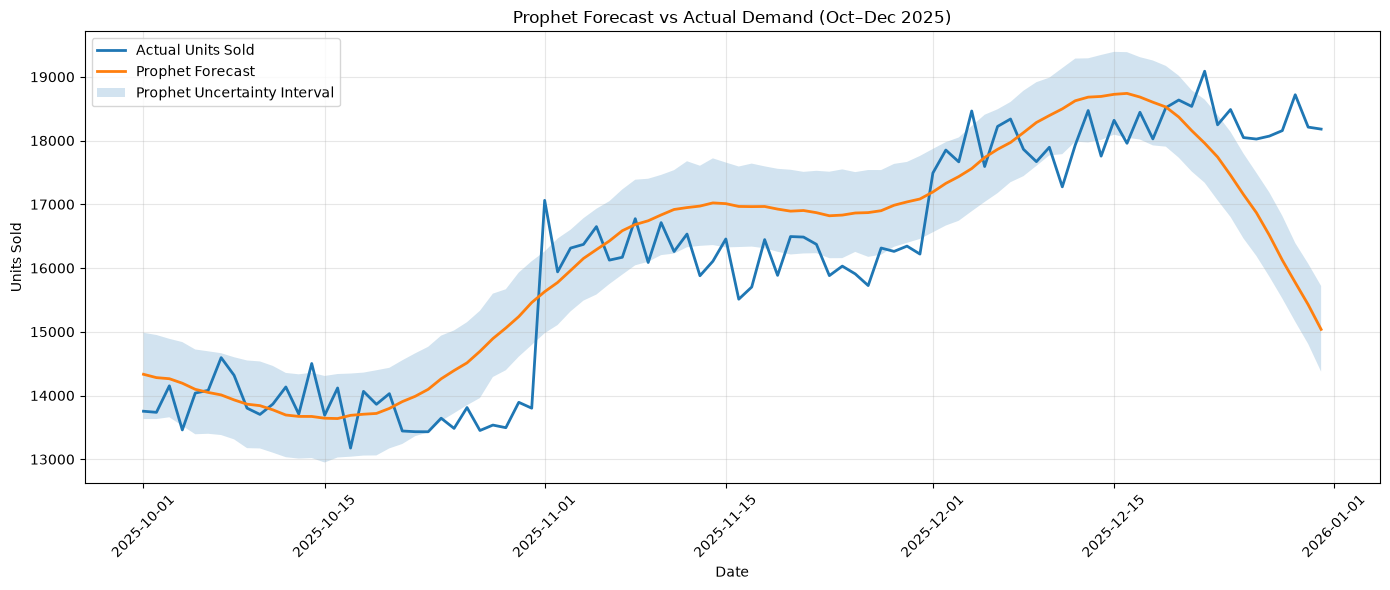

In [48]:

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    prophet_results["ds"],
    prophet_results["y"],
    label="Actual Units Sold",
    linewidth=2
)

plt.plot(
    prophet_results["ds"],
    prophet_results["yhat"],
    label="Prophet Forecast",
    linewidth=2
)

plt.fill_between(
    prophet_results["ds"],
    prophet_results["yhat_lower"],
    prophet_results["yhat_upper"],
    alpha=0.2,
    label="Prophet Uncertainty Interval"
)

plt.title("Prophet Forecast vs Actual Demand (Oct–Dec 2025)")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

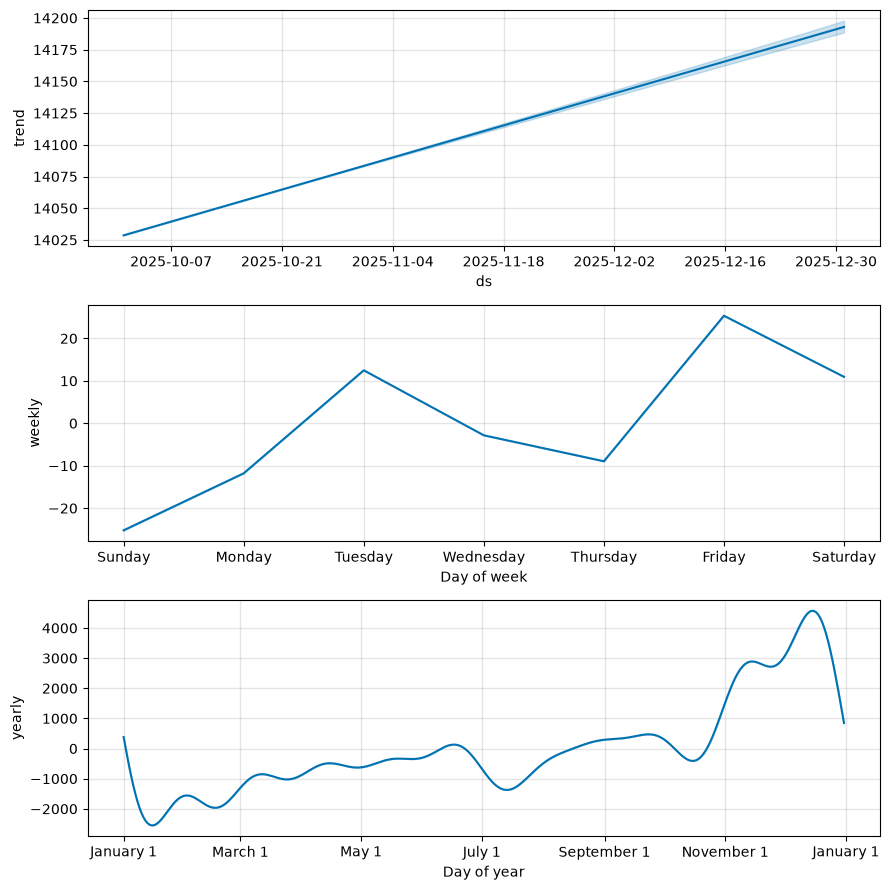

In [49]:

# Display Prophet's trend and seasonal components
fig = model.plot_components(forecast)

plt.tight_layout()
plt.show()

In [50]:

# Experiment: use a smoother yearly seasonal pattern
model_tuned = Prophet(
    yearly_seasonality=5,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Train on the same training period
model_tuned.fit(train_prophet)

# Forecast the same 92 test days
forecast_tuned = model_tuned.predict(test_prophet[["ds"]])

tuned_results = test_prophet.merge(
    forecast_tuned[["ds", "yhat", "yhat_lower", "yhat_upper"]],
    on="ds",
    how="left"
)

# Calculate evaluation metrics
actual = tuned_results["y"]
predicted = tuned_results["yhat"]

mae_tuned = mean_absolute_error(actual, predicted)
rmse_tuned = np.sqrt(mean_squared_error(actual, predicted))
mape_tuned = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("TUNED PROPHET RESULTS")
print(f"MAE:  {mae_tuned:.2f} units")
print(f"RMSE: {rmse_tuned:.2f} units")
print(f"MAPE: {mape_tuned:.2f}%")

print("\nCOMPARISON")
print(f"Seasonal-naive MAPE: 3.24%")
print(f"Original Prophet MAPE: {mape_prophet:.2f}%")
print(f"Tuned Prophet MAPE: {mape_tuned:.2f}%")

21:31:32 - cmdstanpy - INFO - Chain [1] start processing
21:31:32 - cmdstanpy - INFO - Chain [1] done processing


TUNED PROPHET RESULTS
MAE:  972.44 units
RMSE: 1262.83 units
MAPE: 5.91%

COMPARISON
Seasonal-naive MAPE: 3.24%
Original Prophet MAPE: 4.35%
Tuned Prophet MAPE: 5.91%


In [51]:

# Experiment 3: Prophet with weekly seasonality only
model_weekly = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=True,
    daily_seasonality=False
)

model_weekly.fit(train_prophet)

forecast_weekly = model_weekly.predict(test_prophet[["ds"]])

weekly_results = test_prophet.merge(
    forecast_weekly[["ds", "yhat"]],
    on="ds",
    how="left"
)

actual = weekly_results["y"]
predicted = weekly_results["yhat"]

mae_weekly = mean_absolute_error(actual, predicted)
rmse_weekly = np.sqrt(mean_squared_error(actual, predicted))
mape_weekly = np.mean(
    np.abs((actual - predicted) / actual)
) * 100

print("PROPHET WITHOUT YEARLY SEASONALITY")
print(f"MAE:  {mae_weekly:.2f} units")
print(f"RMSE: {rmse_weekly:.2f} units")
print(f"MAPE: {mape_weekly:.2f}%")

print("\nREFERENCE MAPE")
print(f"Seasonal-naive: {3.24:.2f}%")
print(f"Original Prophet: {mape_prophet:.2f}%")
print(f"Tuned Prophet: {mape_tuned:.2f}%")
print(f"Weekly-only Prophet: {mape_weekly:.2f}%")

21:32:04 - cmdstanpy - INFO - Chain [1] start processing
21:32:04 - cmdstanpy - INFO - Chain [1] done processing


PROPHET WITHOUT YEARLY SEASONALITY
MAE:  2781.04 units
RMSE: 3337.05 units
MAPE: 16.21%

REFERENCE MAPE
Seasonal-naive: 3.24%
Original Prophet: 4.35%
Tuned Prophet: 5.91%
Weekly-only Prophet: 16.21%


In [52]:

comparison = pd.DataFrame([
    {
        "model": "Seasonal-naive baseline",
        "MAE": mae_clean,
        "RMSE": rmse_clean,
        "MAPE_percent": mape_clean
    },
    {
        "model": "Prophet - default yearly seasonality",
        "MAE": mae_prophet,
        "RMSE": rmse_prophet,
        "MAPE_percent": mape_prophet
    },
    {
        "model": "Prophet - yearly Fourier order 5",
        "MAE": mae_tuned,
        "RMSE": rmse_tuned,
        "MAPE_percent": mape_tuned
    },
    {
        "model": "Prophet - weekly seasonality only",
        "MAE": mae_weekly,
        "RMSE": rmse_weekly,
        "MAPE_percent": mape_weekly
    }
])

comparison = comparison.sort_values("MAPE_percent").reset_index(drop=True)

display(comparison.round(2))

# Save the comparison for the project report
comparison.to_csv(
    "../reports/forecast_model_comparison.csv",
    index=False
)

print("Model comparison saved.")

,model,MAE,RMSE,MAPE_percent
0,Seasonal-naive baseline,515.37,623.17,3.24
1,Prophet - default yearly seasonality,702.47,920.48,4.35
2,Prophet - yearly Fourier order 5,972.44,1262.83,5.91
3,Prophet - weekly seasonality only,2781.04,3337.05,16.21


OSError: Cannot save file into a non-existent directory: '../reports'

In [53]:

from pathlib import Path

# Find the RetailPulse project directory
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

# Create the reports folder if it doesn't exist
reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

# Save the model comparison
output_path = reports_dir / "forecast_model_comparison.csv"

comparison.to_csv(output_path, index=False)

print("Model comparison saved successfully!")
print("File location:", output_path.resolve())

Model comparison saved successfully!
File location: /Users/venumudike/RetailPulse/reports/forecast_model_comparison.csv


In [54]:

from pathlib import Path
import duckdb

data_dir = Path(
    "/Users/venumudike/Downloads/archive/retail_clean_dataset"
)
promotions_path = data_dir / "promotions.csv"

promotions = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{promotions_path}')
    LIMIT 10
""").fetchdf()

print("Promotion data columns:")
print(promotions.columns.tolist())

print("\nSample promotion records:")
display(promotions)

Promotion data columns:
['promo_id', 'promo_name', 'start_date', 'end_date', 'discount_pct', 'promo_type', 'target_type', 'target_value']

Sample promotion records:


,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO001,Spring Discount Days,2024-07-28,2024-08-02,15.1,BOGO,Brand,NovaFresh
1,PROMO002,Summer Savings Event,2023-03-09,2023-03-21,7.0,Bundle Offer,All,All
2,PROMO003,Payday Discount Days,2025-04-30,2025-05-26,10.2,BOGO,Brand,ZestyCo
3,PROMO004,Super Sale,2025-06-07,2025-06-17,15.9,Clearance,SKU,SKU01108
4,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,Bundle Offer,All,All
5,PROMO006,Spring Savings Event,2025-09-18,2025-10-04,11.1,Flat Discount,Brand,MetroBrand
6,PROMO007,Super Offer,2025-09-11,2025-10-09,8.5,Clearance,Category,Health & Wellness
7,PROMO008,Winter Deal Days,2023-02-24,2023-03-06,49.1,Flat Discount,Brand,BasicNeeds
8,PROMO009,Grand Blowout,2024-10-30,2024-11-26,9.9,Bundle Offer,Category,Snacks & Confectionery
9,PROMO010,Spring Fest,2023-08-19,2023-09-15,12.7,BOGO,All,All


In [55]:

promotion_summary = con.execute(f"""
    SELECT
        COUNT(*) AS total_promotions,
        COUNT(DISTINCT promo_id) AS unique_promo_ids,
        MIN(start_date) AS earliest_start_date,
        MAX(end_date) AS latest_end_date,
        SUM(
            CASE
                WHEN start_date IS NULL OR end_date IS NULL
                THEN 1 ELSE 0
            END
        ) AS missing_dates,
        SUM(
            CASE
                WHEN start_date > end_date
                THEN 1 ELSE 0
            END
        ) AS invalid_date_ranges,
        MIN(discount_pct) AS minimum_discount_pct,
        MAX(discount_pct) AS maximum_discount_pct
    FROM read_csv_auto('{promotions_path}')
""").fetchdf()

display(promotion_summary.T)

,0
total_promotions,100
unique_promo_ids,100
earliest_start_date,2022-01-23 00:00:00
latest_end_date,2025-11-21 00:00:00
missing_dates,0.0
invalid_date_ranges,0.0
minimum_discount_pct,5.0
maximum_discount_pct,49.8


In [56]:

sku_master_path = data_dir / "sku_master.csv"

sku_sample = con.execute(f"""
    SELECT *
    FROM read_csv_auto('{sku_master_path}')
    LIMIT 10
""").fetchdf()

print("SKU master columns:")
print(sku_sample.columns.tolist())

print("\nSample product records:")
display(sku_sample)

SKU master columns:
['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price', 'cost_price', 'brand']

Sample product records:


,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch
3,SKU00004,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,233.64,156.32,SunriseFoods
4,SKU00005,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,138.50,83.46,SunriseFoods
5,SKU00006,UrbanBite OTC Medicine 100g,Health & Wellness,OTC Medicine,1413.92,830.81,UrbanBite
6,SKU00007,GreenValley Energy Drinks Pack of 12,Beverages,Energy Drinks,129.75,78.97,GreenValley
7,SKU00008,CleanWave Frozen Vegetables 100g,Frozen Foods,Frozen Vegetables,492.11,358.31,CleanWave
8,SKU00009,SmartBuy Frozen Vegetables Medium,Frozen Foods,Frozen Vegetables,251.86,178.03,SmartBuy
9,SKU00010,SparkleClean Footwear 250ml,Apparel & Footwear,Footwear,1602.79,1096.65,SparkleClean


In [57]:

sku_master_path = data_dir / "sku_master.csv"

target_check = con.execute(f"""
    WITH products AS (
        SELECT sku_id, brand, category
        FROM read_csv_auto('{sku_master_path}')
    ),
    promos AS (
        SELECT promo_id, target_type, target_value
        FROM read_csv_auto('{promotions_path}')
    )
    SELECT
        p.target_type,
        COUNT(*) AS total_promotions,
        SUM(
            CASE
                WHEN p.target_type = 'All' THEN 1
                WHEN p.target_type = 'SKU'
                     AND EXISTS (
                         SELECT 1 FROM products s
                         WHERE s.sku_id = p.target_value
                     ) THEN 1
                WHEN p.target_type = 'Brand'
                     AND EXISTS (
                         SELECT 1 FROM products s
                         WHERE LOWER(TRIM(s.brand)) =
                               LOWER(TRIM(p.target_value))
                     ) THEN 1
                WHEN p.target_type = 'Category'
                     AND EXISTS (
                         SELECT 1 FROM products s
                         WHERE LOWER(TRIM(s.category)) =
                               LOWER(TRIM(p.target_value))
                     ) THEN 1
                ELSE 0
            END
        ) AS promotions_with_matching_targets
    FROM promos p
    GROUP BY p.target_type
    ORDER BY p.target_type
""").fetchdf()

display(target_check)

,target_type,total_promotions,promotions_with_matching_targets
0,All,19,19.0
1,Brand,21,21.0
2,Category,38,38.0
3,SKU,22,22.0


In [58]:

promotion_sales_check = con.execute(f"""
    WITH sales AS (
        SELECT
            COUNT(*) AS total_sales_rows,
            COUNT(promo_id) AS rows_with_promo_id,
            COUNT(DISTINCT promo_id) AS unique_sales_promo_ids
        FROM read_csv_auto('{sales_path}', sample_size=10000)
    ),
    promos AS (
        SELECT DISTINCT promo_id
        FROM read_csv_auto('{promotions_path}')
    ),
    sales_promo_ids AS (
        SELECT
            DISTINCT promo_id
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        WHERE promo_id IS NOT NULL
    )
    SELECT
        s.total_sales_rows,
        s.rows_with_promo_id,
        s.total_sales_rows - s.rows_with_promo_id
            AS rows_without_promo_id,
        s.unique_sales_promo_ids,
        (SELECT COUNT(*)
         FROM sales_promo_ids sp
         LEFT JOIN promos p USING (promo_id)
         WHERE p.promo_id IS NULL)
            AS sales_promo_ids_missing_from_master
    FROM sales s
""").fetchdf()

display(promotion_sales_check.T)

,0
total_sales_rows,9972038
rows_with_promo_id,2090351
rows_without_promo_id,7881687
unique_sales_promo_ids,96
sales_promo_ids_missing_from_master,0


In [59]:

unused_promotions = con.execute(f"""
    WITH master AS (
        SELECT
            promo_id,
            promo_name,
            start_date,
            end_date,
            discount_pct,
            target_type,
            target_value
        FROM read_csv_auto('{promotions_path}')
    ),
    used AS (
        SELECT DISTINCT promo_id
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        WHERE promo_id IS NOT NULL
    )
    SELECT m.*
    FROM master m
    LEFT JOIN used u USING (promo_id)
    WHERE u.promo_id IS NULL
    ORDER BY m.promo_id
""").fetchdf()

print("Promotions absent from sales transactions:", len(unused_promotions))
display(unused_promotions)

Promotions absent from sales transactions: 4


,promo_id,promo_name,start_date,end_date,discount_pct,target_type,target_value
0,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,All,All
1,PROMO028,Back to School Fest,2023-04-12,2023-04-18,19.8,All,All
2,PROMO038,Grand Bonanza,2024-06-26,2024-07-15,48.5,Brand,MetroBrand
3,PROMO070,Mid-Season Discount Days,2024-09-26,2024-10-06,47.0,Category,Dairy & Bakery


In [60]:

promotion_period_sales = con.execute(f"""
    WITH promotion_periods AS (
        SELECT
            promo_id,
            promo_name,
            start_date,
            end_date,
            target_type,
            target_value
        FROM read_csv_auto('{promotions_path}')
        WHERE promo_id IN (
            'PROMO005', 'PROMO028', 'PROMO038', 'PROMO070'
        )
    ),
    daily_sales AS (
        SELECT
            date,
            SUM(quantity) AS units_sold,
            SUM(total_value) AS sales_value,
            COUNT(*) AS transaction_lines,
            COUNT(promo_id) AS lines_with_promo_id
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        GROUP BY date
    )
    SELECT
        p.promo_id,
        p.promo_name,
        p.start_date,
        p.end_date,
        p.target_type,
        p.target_value,
        COUNT(d.date) AS days_with_sales_data,
        SUM(d.units_sold) AS total_units_sold,
        SUM(d.sales_value) AS total_sales_value,
        SUM(d.transaction_lines) AS total_transaction_lines,
        SUM(d.lines_with_promo_id) AS lines_with_any_promo_id
    FROM promotion_periods p
    LEFT JOIN daily_sales d
        ON d.date BETWEEN p.start_date AND p.end_date
    GROUP BY
        p.promo_id, p.promo_name, p.start_date, p.end_date,
        p.target_type, p.target_value
    ORDER BY p.promo_id
""").fetchdf()

display(promotion_period_sales)

,promo_id,promo_name,start_date,end_date,target_type,target_value,days_with_sales_data,total_units_sold,total_sales_value,total_transaction_lines,lines_with_any_promo_id
0,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,All,All,17,206784.0,6.933394e+07,110097.0,110097.0
1,PROMO028,Back to School Fest,2023-04-12,2023-04-18,All,All,7,82822.0,3.981469e+07,43781.0,43781.0
2,PROMO038,Grand Bonanza,2024-06-26,2024-07-15,Brand,MetroBrand,20,246345.0,1.183806e+08,131245.0,131245.0
3,PROMO070,Mid-Season Discount Days,2024-09-26,2024-10-06,Category,Dairy & Bakery,11,149216.0,6.787752e+07,79301.0,79301.0


In [61]:

targeted_promotion_check = con.execute(f"""
    WITH products AS (
        SELECT sku_id, brand, category
        FROM read_csv_auto('{data_dir / "sku_master.csv"}')
    ),
    promos AS (
        SELECT promo_id, start_date, end_date,
               target_type, target_value
        FROM read_csv_auto('{promotions_path}')
        WHERE promo_id IN ('PROMO038', 'PROMO070')
    ),
    sales AS (
        SELECT date, sku_id, quantity, total_value,
               promo_id, discount_pct
        FROM read_csv_auto('{sales_path}', sample_size=10000)
    )
    SELECT
        p.promo_id,
        p.target_type,
        p.target_value,
        COUNT(*) AS matching_product_sales_lines,
        SUM(s.quantity) AS units_sold,
        SUM(s.total_value) AS sales_value,
        COUNT(s.promo_id) AS lines_with_any_promo_id,
        SUM(CASE WHEN s.discount_pct > 0
                 THEN 1 ELSE 0 END) AS lines_with_discount
    FROM promos p
    JOIN sales s
      ON s.date BETWEEN p.start_date AND p.end_date
    JOIN products pr
      ON pr.sku_id = s.sku_id
     AND (
         (p.target_type = 'Brand'
          AND LOWER(TRIM(pr.brand)) = LOWER(TRIM(p.target_value)))
         OR
         (p.target_type = 'Category'
          AND LOWER(TRIM(pr.category)) = LOWER(TRIM(p.target_value)))
     )
    GROUP BY p.promo_id, p.target_type, p.target_value
    ORDER BY p.promo_id
""").fetchdf()

display(targeted_promotion_check)

,promo_id,target_type,target_value,matching_product_sales_lines,units_sold,sales_value,lines_with_any_promo_id,lines_with_discount
0,PROMO038,Brand,MetroBrand,4133,7781.0,2914607.18,4133,4133.0
1,PROMO070,Category,Dairy & Bakery,7244,13619.0,2168306.93,7244,7244.0


In [62]:

recorded_promo_ids = con.execute(f"""
    WITH products AS (
        SELECT sku_id, brand, category
        FROM read_csv_auto('{data_dir / "sku_master.csv"}')
    )
    SELECT
        CASE
            WHEN LOWER(TRIM(pr.brand)) = 'metrobrand'
                THEN 'PROMO038 target: MetroBrand'
            ELSE 'PROMO070 target: Dairy & Bakery'
        END AS target_group,
        s.promo_id AS recorded_promo_id,
        COUNT(*) AS transaction_lines,
        SUM(s.quantity) AS units_sold,
        SUM(CASE WHEN s.discount_pct > 0
                 THEN 1 ELSE 0 END) AS discounted_lines
    FROM read_csv_auto('{sales_path}', sample_size=10000) s
    JOIN products pr ON s.sku_id = pr.sku_id
    WHERE
        (
            LOWER(TRIM(pr.brand)) = 'metrobrand'
            AND s.date BETWEEN DATE '2024-06-26'
                           AND DATE '2024-07-15'
        )
        OR
        (
            LOWER(TRIM(pr.category)) = 'dairy & bakery'
            AND s.date BETWEEN DATE '2024-09-26'
                           AND DATE '2024-10-06'
        )
    GROUP BY 1, 2
    ORDER BY 1, 3 DESC
""").fetchdf()

display(recorded_promo_ids)

,target_group,recorded_promo_id,transaction_lines,units_sold,discounted_lines
0,PROMO038 target: MetroBrand,PROMO045,3889,7275.0,3889.0
1,PROMO038 target: MetroBrand,PROMO081,244,506.0,244.0
2,PROMO038 target: MetroBrand,PROMO094,242,449.0,242.0
3,PROMO070 target: Dairy & Bakery,PROMO094,7002,13170.0,7002.0


In [63]:

promo_ids_to_compare = [
    "PROMO038", "PROMO045", "PROMO070",
    "PROMO081", "PROMO094"
]

promo_id_list = ", ".join(
    f"'{promo_id}'" for promo_id in promo_ids_to_compare
)

promotion_details = con.execute(f"""
    SELECT
        promo_id,
        promo_name,
        start_date,
        end_date,
        discount_pct,
        promo_type,
        target_type,
        target_value
    FROM read_csv_auto('{promotions_path}')
    WHERE promo_id IN ({promo_id_list})
    ORDER BY promo_id
""").fetchdf()

display(promotion_details)

,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO038,Grand Bonanza,2024-06-26,2024-07-15,48.5,Flat Discount,Brand,MetroBrand
1,PROMO045,Payday Discount Days,2024-06-21,2024-07-20,22.6,Flat Discount,All,All
2,PROMO070,Mid-Season Discount Days,2024-09-26,2024-10-06,47.0,Clearance,Category,Dairy & Bakery
3,PROMO081,Mega Bonanza,2024-06-18,2024-07-12,28.0,Clearance,Category,Frozen Foods
4,PROMO094,Mega Fest,2024-09-23,2024-10-08,27.0,Percentage Discount,All,All


In [64]:

promotion_usage_audit = con.execute(f"""
    WITH master AS (
        SELECT
            promo_id,
            promo_name,
            start_date,
            end_date,
            discount_pct,
            target_type,
            target_value
        FROM read_csv_auto('{promotions_path}')
    ),
    usage AS (
        SELECT
            promo_id,
            COUNT(*) AS transaction_lines,
            SUM(quantity) AS units_sold,
            SUM(total_value) AS recorded_sales_value
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        WHERE promo_id IS NOT NULL
        GROUP BY promo_id
    )
    SELECT
        m.promo_id,
        m.promo_name,
        m.start_date,
        m.end_date,
        m.discount_pct AS scheduled_discount_pct,
        m.target_type,
        m.target_value,
        COALESCE(u.transaction_lines, 0) AS transaction_lines,
        COALESCE(u.units_sold, 0) AS units_sold,
        COALESCE(u.recorded_sales_value, 0) AS recorded_sales_value,
        CASE
            WHEN u.promo_id IS NULL THEN 'No transaction reference'
            ELSE 'Transaction reference found'
        END AS usage_status
    FROM master m
    LEFT JOIN usage u USING (promo_id)
    ORDER BY transaction_lines, m.promo_id
""").fetchdf()

display(promotion_usage_audit.head(15))
print("Promotions in master:", len(promotion_usage_audit))
print(
    "Promotions with no transaction references:",
    (promotion_usage_audit["transaction_lines"] == 0).sum()
)

,promo_id,promo_name,start_date,end_date,scheduled_discount_pct,target_type,target_value,transaction_lines,units_sold,recorded_sales_value,usage_status
0,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,All,All,0,0.0,0.00,No transaction reference
1,PROMO028,Back to School Fest,2023-04-12,2023-04-18,19.8,All,All,0,0.0,0.00,No transaction reference
2,PROMO038,Grand Bonanza,2024-06-26,2024-07-15,48.5,Brand,MetroBrand,0,0.0,0.00,No transaction reference
3,PROMO070,Mid-Season Discount Days,2024-09-26,2024-10-06,47.0,Category,Dairy & Bakery,0,0.0,0.00,No transaction reference
4,PROMO012,Super Sale,2023-12-25,2024-01-16,17.2,SKU,SKU03430,3,6.0,1729.77,Transaction reference found
5,PROMO027,Year-End Deal Days,2025-05-26,2025-06-01,20.8,SKU,SKU02605,3,12.0,639.43,Transaction reference found
6,PROMO053,Year-End Sale,2025-05-04,2025-05-23,19.5,SKU,SKU00800,4,9.0,1505.73,Transaction reference found
7,PROMO025,Anniversary Savings Event,2023-12-03,2023-12-09,7.0,SKU,SKU01419,5,15.0,9755.37,Transaction reference found
8,PROMO029,Festive Fest,2023-10-27,2023-11-05,41.2,SKU,SKU02021,5,12.0,2092.88,Transaction reference found
9,PROMO068,Weekend Deal Days,2023-08-20,2023-09-03,31.2,SKU,SKU02406,7,18.0,2618.97,Transaction reference found


Promotions in master: 100
Promotions with no transaction references: 4


In [65]:

promotion_date_audit = con.execute(f"""
    WITH master AS (
        SELECT
            promo_id,
            start_date,
            end_date
        FROM read_csv_auto('{promotions_path}')
    ),
    sales AS (
        SELECT
            promo_id,
            date,
            COUNT(*) AS transaction_lines
        FROM read_csv_auto('{sales_path}', sample_size=10000)
        WHERE promo_id IS NOT NULL
        GROUP BY promo_id, date
    )
    SELECT
        COUNT(DISTINCT s.promo_id) AS promotion_ids_used,
        SUM(s.transaction_lines) AS total_referenced_lines,
        SUM(
            CASE WHEN s.date BETWEEN m.start_date AND m.end_date
                 THEN s.transaction_lines ELSE 0 END
        ) AS lines_within_scheduled_dates,
        SUM(
            CASE WHEN s.date < m.start_date OR s.date > m.end_date
                 THEN s.transaction_lines ELSE 0 END
        ) AS lines_outside_scheduled_dates
    FROM sales s
    JOIN master m USING (promo_id)
""").fetchdf()

display(promotion_date_audit.T)

,0
promotion_ids_used,96.0
total_referenced_lines,2090351.0
lines_within_scheduled_dates,2090351.0
lines_outside_scheduled_dates,0.0


In [66]:

discount_audit = con.execute(f"""
    WITH master AS (
        SELECT promo_id, discount_pct AS scheduled_discount_pct
        FROM read_csv_auto('{promotions_path}')
    ),
    sales AS (
        SELECT
            s.promo_id,
            COUNT(*) AS transaction_lines,
            AVG(s.discount_pct) AS average_transaction_discount_pct,
            MIN(s.discount_pct) AS minimum_transaction_discount_pct,
            MAX(s.discount_pct) AS maximum_transaction_discount_pct,
            SUM(
                CASE
                    WHEN ABS(s.discount_pct - m.scheduled_discount_pct) > 0.1
                    THEN 1 ELSE 0
                END
            ) AS lines_with_discount_difference
        FROM read_csv_auto('{sales_path}', sample_size=10000) s
        JOIN master m USING (promo_id)
        WHERE s.promo_id IS NOT NULL
        GROUP BY s.promo_id
    )
    SELECT
        COUNT(*) AS promotion_ids_audited,
        SUM(transaction_lines) AS total_transaction_lines,
        SUM(lines_with_discount_difference)
            AS lines_differing_from_scheduled_discount,
        ROUND(
            100.0 * SUM(lines_with_discount_difference)
            / SUM(transaction_lines), 2
        ) AS percent_lines_differing
    FROM sales
""").fetchdf()

display(discount_audit.T)

,0
promotion_ids_audited,96.0
total_transaction_lines,2090351.0
lines_differing_from_scheduled_discount,0.0
percent_lines_differing,0.0


In [67]:

# Create one row per day and summarize scheduled promotions.
daily_promo_features = con.execute(f"""
    WITH calendar AS (
        SELECT CAST(generate_series AS DATE) AS date
        FROM generate_series(
            DATE '2022-01-01',
            DATE '2025-12-31',
            INTERVAL 1 DAY
        )
    ),
    promotions AS (
        SELECT
            promo_id,
            CAST(start_date AS DATE) AS start_date,
            CAST(end_date AS DATE) AS end_date,
            discount_pct,
            target_type
        FROM read_csv_auto('{promotions_path}')
    )
    SELECT
        c.date,
        COUNT(p.promo_id) AS active_promotion_count,
        COUNT(p.promo_id) FILTER (
            WHERE p.target_type = 'All'
        ) AS active_all_target_promotions,
        COUNT(p.promo_id) FILTER (
            WHERE p.target_type IN ('Brand', 'Category', 'SKU')
        ) AS active_targeted_promotions,
        COALESCE(MAX(p.discount_pct), 0)
            AS max_scheduled_discount_pct
    FROM calendar c
    LEFT JOIN promotions p
        ON c.date BETWEEN p.start_date AND p.end_date
    GROUP BY c.date
    ORDER BY c.date
""").fetchdf()

daily_promo_features["date"] = pd.to_datetime(
    daily_promo_features["date"]
)

# Join the scheduled promotion features to cleaned daily sales.
daily_with_promos = daily_clean.merge(
    daily_promo_features,
    on="date",
    how="left",
    validate="one_to_one"
)

# Display basic validation results.
print("Daily promotion feature rows:", len(daily_promo_features))
print("Joined daily sales rows:", len(daily_with_promos))
print(
    "Missing promotion feature values:",
    int(daily_with_promos[
        [
            "active_promotion_count",
            "active_all_target_promotions",
            "active_targeted_promotions",
            "max_scheduled_discount_pct"
        ]
    ].isna().sum().sum())
)
print(
    "Date range:",
    daily_with_promos["date"].min().date(),
    "to",
    daily_with_promos["date"].max().date()
)

print("\nSample daily features:")
display(daily_with_promos.head(10))

print("\nDays with the most scheduled promotions:")
display(
    daily_with_promos.nlargest(
        10, "active_promotion_count"
    )[
        [
            "date",
            "units_sold",
            "active_promotion_count",
            "active_all_target_promotions",
            "active_targeted_promotions",
            "max_scheduled_discount_pct"
        ]
    ]
)

Daily promotion feature rows: 1461
Joined daily sales rows: 1461
Missing promotion feature values: 0
Date range: 2022-01-01 to 2025-12-31

Sample daily features:


,date,units_sold,recorded_sales_value,transaction_lines,active_promotion_count,active_all_target_promotions,active_targeted_promotions,max_scheduled_discount_pct
0,2022-01-01,9529.0,5796378.22,5068,0,0,0,0.0
1,2022-01-02,9637.0,5926177.21,5132,0,0,0,0.0
2,2022-01-03,9679.0,6028251.58,5163,0,0,0,0.0
3,2022-01-04,9749.0,5844144.77,5120,0,0,0,0.0
4,2022-01-05,9320.0,5830410.96,4970,0,0,0,0.0
5,2022-01-06,9464.0,5862412.67,5009,0,0,0,0.0
6,2022-01-07,9563.0,5938102.09,5109,0,0,0,0.0
7,2022-01-08,9640.0,6185634.77,5213,0,0,0,0.0
8,2022-01-09,9249.0,5779960.50,4874,0,0,0,0.0
9,2022-01-10,9605.0,6043313.17,5128,0,0,0,0.0



Days with the most scheduled promotions:


,date,units_sold,active_promotion_count,active_all_target_promotions,active_targeted_promotions,max_scheduled_discount_pct
34,2022-02-04,10122.0,4,0,4,48.6
35,2022-02-05,10260.0,4,0,4,48.6
36,2022-02-06,9805.0,4,0,4,48.6
37,2022-02-07,9577.0,4,0,4,48.6
38,2022-02-08,9922.0,4,0,4,48.6
39,2022-02-09,10171.0,4,0,4,48.6
40,2022-02-10,9448.0,4,0,4,48.6
41,2022-02-11,9638.0,4,0,4,48.6
42,2022-02-12,9974.0,4,0,4,48.6
43,2022-02-13,10240.0,4,0,4,48.6


In [68]:

from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

features_dir = project_root / "data" / "processed"
features_dir.mkdir(parents=True, exist_ok=True)

features_path = features_dir / "daily_sales_with_promotion_features.csv"

daily_with_promos.to_csv(features_path, index=False)

print("Saved feature table to:")
print(features_path)
print("\nRows saved:", len(daily_with_promos))
print("Columns saved:", daily_with_promos.columns.tolist())

Saved feature table to:
/Users/venumudike/RetailPulse/data/processed/daily_sales_with_promotion_features.csv

Rows saved: 1461
Columns saved: ['date', 'units_sold', 'recorded_sales_value', 'transaction_lines', 'active_promotion_count', 'active_all_target_promotions', 'active_targeted_promotions', 'max_scheduled_discount_pct']


In [69]:
# Create calendar features
daily_model_data = daily_with_promos.copy()

daily_model_data["date"] = pd.to_datetime(daily_model_data["date"])

daily_model_data["day_of_week"] = daily_model_data["date"].dt.dayofweek
daily_model_data["day_of_month"] = daily_model_data["date"].dt.day
daily_model_data["month"] = daily_model_data["date"].dt.month
daily_model_data["quarter"] = daily_model_data["date"].dt.quarter
daily_model_data["year"] = daily_model_data["date"].dt.year
daily_model_data["is_weekend"] = (
    daily_model_data["day_of_week"] >= 5
).astype(int)

print("Rows:", len(daily_model_data))
print("\nNew calendar features:")
print([
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "year",
    "is_weekend"
])

display(daily_model_data.head())

Rows: 1461

New calendar features:
['day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend']


,date,units_sold,recorded_sales_value,transaction_lines,active_promotion_count,active_all_target_promotions,active_targeted_promotions,max_scheduled_discount_pct,day_of_week,day_of_month,month,quarter,year,is_weekend
0,2022-01-01,9529.0,5796378.22,5068,0,0,0,0.0,5,1,1,1,2022,1
1,2022-01-02,9637.0,5926177.21,5132,0,0,0,0.0,6,2,1,1,2022,1
2,2022-01-03,9679.0,6028251.58,5163,0,0,0,0.0,0,3,1,1,2022,0
3,2022-01-04,9749.0,5844144.77,5120,0,0,0,0.0,1,4,1,1,2022,0
4,2022-01-05,9320.0,5830410.96,4970,0,0,0,0.0,2,5,1,1,2022,0


In [70]:
# Check for missing values
print("Missing values per column:")
print(daily_model_data.isna().sum())

# Check data types
print("\nColumn data types:")
print(daily_model_data.dtypes)

# Confirm date coverage and row count
print("\nTotal rows:", len(daily_model_data))
print("Duplicate dates:", daily_model_data["date"].duplicated().sum())
print("Date range:", daily_model_data["date"].min(),
      "to", daily_model_data["date"].max())

Missing values per column:
date                            0
units_sold                      0
recorded_sales_value            0
transaction_lines               0
active_promotion_count          0
active_all_target_promotions    0
active_targeted_promotions      0
max_scheduled_discount_pct      0
day_of_week                     0
day_of_month                    0
month                           0
quarter                         0
year                            0
is_weekend                      0
dtype: int64

Column data types:
date                            datetime64[us]
units_sold                             float64
recorded_sales_value                   float64
transaction_lines                        int64
active_promotion_count                   int64
active_all_target_promotions             int64
active_targeted_promotions               int64
max_scheduled_discount_pct             float64
day_of_week                              int32
day_of_month                             

In [71]:
# Check for missing values
print("Missing values per column:")
print(daily_model_data.isna().sum())

# Check data types
print("\nColumn data types:")
print(daily_model_data.dtypes)

# Confirm date coverage and row count
print("\nTotal rows:", len(daily_model_data))
print("Duplicate dates:", daily_model_data["date"].duplicated().sum())
print("Date range:", daily_model_data["date"].min(),
      "to", daily_model_data["date"].max())

Missing values per column:
date                            0
units_sold                      0
recorded_sales_value            0
transaction_lines               0
active_promotion_count          0
active_all_target_promotions    0
active_targeted_promotions      0
max_scheduled_discount_pct      0
day_of_week                     0
day_of_month                    0
month                           0
quarter                         0
year                            0
is_weekend                      0
dtype: int64

Column data types:
date                            datetime64[us]
units_sold                             float64
recorded_sales_value                   float64
transaction_lines                        int64
active_promotion_count                   int64
active_all_target_promotions             int64
active_targeted_promotions               int64
max_scheduled_discount_pct             float64
day_of_week                              int32
day_of_month                             

In [72]:
# Create a separate dataset for forecasting
ml_data = daily_model_data.copy()
ml_data = ml_data.sort_values("date").reset_index(drop=True)

# Previous-day and previous-week sales
ml_data["units_lag_1"] = ml_data["units_sold"].shift(1)
ml_data["units_lag_7"] = ml_data["units_sold"].shift(7)

# Previous year's sales, aligned by calendar date
ml_data["units_lag_364"] = ml_data["units_sold"].shift(364)

# Previous 7-day average, excluding the current day
ml_data["units_rolling_mean_7"] = (
    ml_data["units_sold"].shift(1).rolling(window=7).mean()
)

print("Dataset shape:", ml_data.shape)
print("\nMissing values in lag features:")
print(
    ml_data[
        [
            "units_lag_1",
            "units_lag_7",
            "units_lag_364",
            "units_rolling_mean_7",
        ]
    ].isna().sum()
)

display(ml_data.tail())

Dataset shape: (1461, 18)

Missing values in lag features:
units_lag_1               1
units_lag_7               7
units_lag_364           364
units_rolling_mean_7      7
dtype: int64


,date,units_sold,recorded_sales_value,transaction_lines,active_promotion_count,active_all_target_promotions,active_targeted_promotions,max_scheduled_discount_pct,day_of_week,day_of_month,month,quarter,year,is_weekend,units_lag_1,units_lag_7,units_lag_364,units_rolling_mean_7
1456,2025-12-27,18070.0,11150223.50,9566,0,0,0,0.0,5,27,12,4,2025,1,18024.0,18636.0,16981.0,18437.857143
1457,2025-12-28,18156.0,11362627.86,9733,0,0,0,0.0,6,28,12,4,2025,1,18070.0,18536.0,17725.0,18357.000000
1458,2025-12-29,18719.0,11784706.79,9916,0,0,0,0.0,0,29,12,4,2025,0,18156.0,19088.0,17725.0,18302.714286
1459,2025-12-30,18211.0,11765631.54,9755,0,0,0,0.0,1,30,12,4,2025,0,18719.0,18247.0,17700.0,18250.000000
1460,2025-12-31,18180.0,11301359.70,9680,0,0,0,0.0,2,31,12,4,2025,0,18211.0,18487.0,11295.0,18244.857143


In [73]:
# Select predictors available for daily forecasting
feature_cols = [
    "day_of_week",
    "day_of_month",
    "month",
    "quarter",
    "is_weekend",
    "active_promotion_count",
    "active_all_target_promotions",
    "active_targeted_promotions",
    "max_scheduled_discount_pct",
    "units_lag_1",
    "units_lag_7",
    "units_lag_364",
    "units_rolling_mean_7",
]

target_col = "units_sold"
test_start = pd.Timestamp("2025-10-01")

# Remove rows with missing lag features
model_data = ml_data.dropna(
    subset=feature_cols + [target_col]
).copy()

# Chronological split — no random shuffling
train_ml = model_data[model_data["date"] < test_start].copy()
test_ml = model_data[model_data["date"] >= test_start].copy()

print("Training rows:", len(train_ml))
print("Training dates:", train_ml["date"].min(), "to", train_ml["date"].max())

print("\nTesting rows:", len(test_ml))
print("Testing dates:", test_ml["date"].min(), "to", test_ml["date"].max())

print("\nMissing predictor values in training:",
      train_ml[feature_cols].isna().sum().sum())

print("Missing predictor values in testing:",
      test_ml[feature_cols].isna().sum().sum())

Training rows: 1005
Training dates: 2022-12-31 00:00:00 to 2025-09-30 00:00:00

Testing rows: 92
Testing dates: 2025-10-01 00:00:00 to 2025-12-31 00:00:00

Missing predictor values in training: 0
Missing predictor values in testing: 0


In [74]:
from sklearn.ensemble import RandomForestRegressor

# Define model inputs and target
X_train = train_ml[feature_cols]
y_train = train_ml[target_col]

X_test = test_ml[feature_cols]
y_test = test_ml[target_col]

# Train the model
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

# Generate one-day-ahead predictions
rf_predictions = rf_model.predict(X_test)

print("Random Forest training completed.")
print("Training observations:", len(X_train))
print("Testing observations:", len(X_test))
print("Number of features:", len(feature_cols))
print("\nFirst 10 predictions:")
print(rf_predictions[:10])

Random Forest training completed.
Training observations: 1005
Testing observations: 92
Number of features: 13

First 10 predictions:
[14566.62126587 14702.10020953 14464.13187211 14425.78319949
 14186.86274567 14242.78991984 13765.76974893 13806.7479073
 14213.73419825 14359.39472727]


In [75]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Calculate Random Forest evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

# MAPE: mean absolute percentage error
rf_mape = np.mean(
    np.abs((y_test.to_numpy() - rf_predictions) / y_test.to_numpy())
) * 100

print("Random Forest Evaluation Results")
print("-" * 35)
print(f"MAE:  {rf_mae:.2f} units")
print(f"RMSE: {rf_rmse:.2f} units")
print(f"MAPE: {rf_mape:.2f}%")

Random Forest Evaluation Results
-----------------------------------
MAE:  416.65 units
RMSE: 512.92 units
MAPE: 2.58%


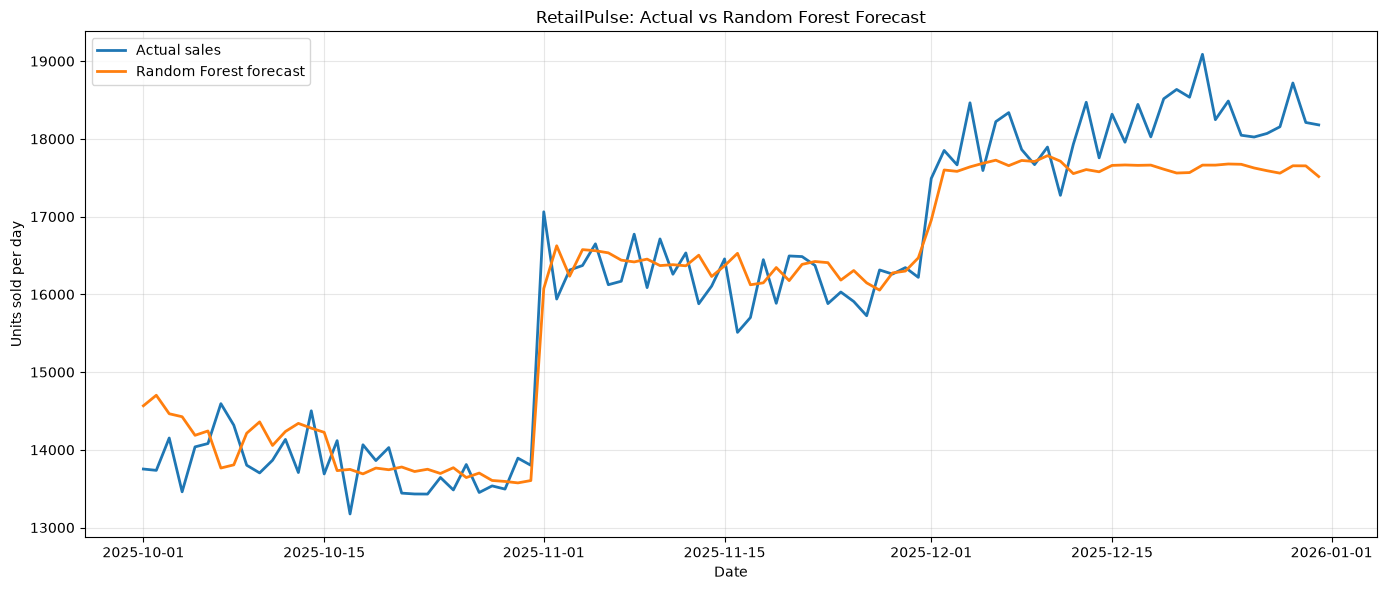

In [76]:
import matplotlib.pyplot as plt

# Build a comparison table
rf_comparison = pd.DataFrame({
    "date": test_ml["date"].to_numpy(),
    "actual_units": y_test.to_numpy(),
    "predicted_units": rf_predictions
})

plt.figure(figsize=(14, 6))

plt.plot(
    rf_comparison["date"],
    rf_comparison["actual_units"],
    label="Actual sales",
    linewidth=2
)

plt.plot(
    rf_comparison["date"],
    rf_comparison["predicted_units"],
    label="Random Forest forecast",
    linewidth=2
)

plt.title("RetailPulse: Actual vs Random Forest Forecast")
plt.xlabel("Date")
plt.ylabel("Units sold per day")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [77]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Use the exact same test dates for both models
comparison = pd.DataFrame({
    "date": test_ml["date"].to_numpy(),
    "actual_units": y_test.to_numpy(),
    "rf_prediction": rf_predictions
})

# Seasonal-naive forecast: same calendar date one year earlier
sales_by_date = daily_clean.set_index("date")["units_sold"]

comparison["seasonal_prediction"] = comparison["date"].map(
    lambda d: sales_by_date.get(
        d - pd.DateOffset(years=1), np.nan
    )
)

# Confirm both models have predictions for every test date
print("Test dates:", len(comparison))
print(
    "Missing seasonal predictions:",
    comparison["seasonal_prediction"].isna().sum()
)

# Calculate metrics for both models
def calculate_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(mean_squared_error(actual, predicted)),
        "MAPE (%)": np.mean(
            np.abs((actual - predicted) / actual)
        ) * 100
    }

actual = comparison["actual_units"].to_numpy()

results = pd.DataFrame({
    "Seasonal-naive": calculate_metrics(
        actual, comparison["seasonal_prediction"].to_numpy()
    ),
    "Random Forest": calculate_metrics(
        actual, comparison["rf_prediction"].to_numpy()
    )
}).T

display(results.round(2))

Test dates: 92
Missing seasonal predictions: 0


,MAE,RMSE,MAPE (%)
Seasonal-naive,515.37,623.17,3.24
Random Forest,416.65,512.92,2.58


Feature importance ranking:


,feature,importance
2,month,0.6206
11,units_lag_364,0.2072
9,units_lag_1,0.1060
12,units_rolling_mean_7,0.0516
1,day_of_month,0.0050
10,units_lag_7,0.0037
8,max_scheduled_discount_pct,0.0024
0,day_of_week,0.0014
5,active_promotion_count,0.0009
7,active_targeted_promotions,0.0005


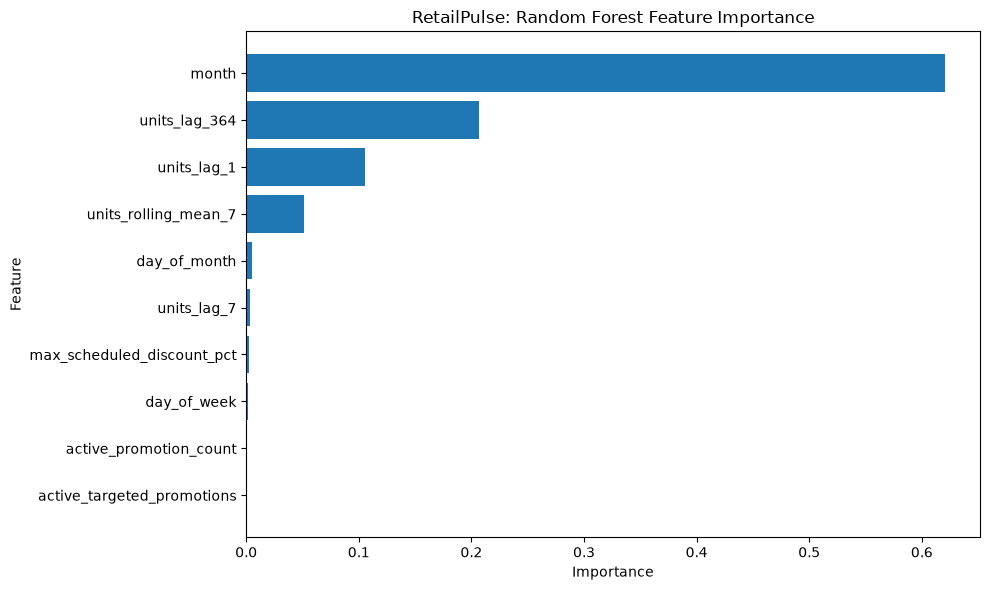

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract Random Forest feature importance
feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf_model.feature_importances_
}).sort_values("importance", ascending=False)

print("Feature importance ranking:")
display(feature_importance.round(4))

# Visualize the 10 most important features
top_features = feature_importance.head(10).sort_values("importance")

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["feature"],
    top_features["importance"]
)
plt.title("RetailPulse: Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [79]:
# Add predictions and errors to the test data
error_analysis = pd.DataFrame({
    "date": test_ml["date"].to_numpy(),
    "actual_units": y_test.to_numpy(),
    "predicted_units": rf_predictions
})

error_analysis["month"] = error_analysis["date"].dt.month

error_analysis["absolute_error"] = (
    error_analysis["actual_units"]
    - error_analysis["predicted_units"]
).abs()

error_analysis["absolute_percentage_error"] = (
    error_analysis["absolute_error"]
    / error_analysis["actual_units"]
    * 100
)

# Summarize performance for each test month
monthly_errors = (
    error_analysis.groupby("month")
    .agg(
        days=("date", "count"),
        actual_avg_units=("actual_units", "mean"),
        predicted_avg_units=("predicted_units", "mean"),
        MAE=("absolute_error", "mean"),
        MAPE=("absolute_percentage_error", "mean")
    )
    .reset_index()
)

monthly_errors["month"] = monthly_errors["month"].map({
    10: "October",
    11: "November",
    12: "December"
})

display(monthly_errors.round(2))

,month,days,actual_avg_units,predicted_avg_units,MAE,MAPE
0,October,31,13813.10,13967.46,372.75,2.70
1,November,30,16233.83,16347.08,321.73,1.99
2,December,31,18133.71,17618.22,552.42,3.01


In [80]:
# Positive bias means overprediction.
# Negative bias means underprediction.

error_analysis["signed_error"] = (
    error_analysis["predicted_units"]
    - error_analysis["actual_units"]
)

bias_by_month = (
    error_analysis.groupby("month")
    .agg(
        mean_prediction_bias=("signed_error", "mean"),
        largest_underprediction=("signed_error", "min"),
        largest_overprediction=("signed_error", "max")
    )
    .reset_index()
)

bias_by_month["month"] = bias_by_month["month"].map({
    10: "October",
    11: "November",
    12: "December"
})

display(bias_by_month.round(2))

,month,mean_prediction_bias,largest_underprediction,largest_overprediction
0,October,154.36,-828.23,966.10
1,November,113.24,-987.22,1016.94
2,December,-515.49,-1425.35,439.26


In [81]:
# Largest underpredictions: actual sales exceeded predictions
print("Top 5 underpredictions:")
display(
    error_analysis
    .sort_values("signed_error", ascending=True)
    [["date", "actual_units", "predicted_units", "signed_error"]]
    .head(5)
    .round(2)
)

# Largest overpredictions: predictions exceeded actual sales
print("\nTop 5 overpredictions:")
display(
    error_analysis
    .sort_values("signed_error", ascending=False)
    [["date", "actual_units", "predicted_units", "signed_error"]]
    .head(5)
    .round(2)
)

Top 5 underpredictions:


/var/folders/tn/lfbvv3ds355bq93nqngn7pk40000gn/T/ipykernel_13464/1856205166.py:8: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,date,actual_units,predicted_units,signed_error
82,2025-12-22,19088.0,17662.65,-1425.35
80,2025-12-20,18636.0,17560.98,-1075.02
89,2025-12-29,18719.0,17654.16,-1064.84
31,2025-11-01,17062.0,16074.78,-987.22
81,2025-12-21,18536.0,17566.74,-969.26



Top 5 overpredictions:


/var/folders/tn/lfbvv3ds355bq93nqngn7pk40000gn/T/ipykernel_13464/1856205166.py:18: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  .round(2)


,date,actual_units,predicted_units,signed_error
46,2025-11-16,15511.0,16527.94,1016.94
1,2025-10-02,13736.0,14702.10,966.10
3,2025-10-04,13460.0,14425.78,965.78
0,2025-10-01,13753.0,14566.62,813.62
32,2025-11-02,15940.0,16625.51,685.51


In [82]:
# Inspect the 5 largest underpredictions
worst_under = (
    error_analysis
    .nsmallest(5, "signed_error")[["date"]]
)

# Inspect the 5 largest overpredictions
worst_over = (
    error_analysis
    .nlargest(5, "signed_error")[["date"]]
)

selected_dates = pd.concat(
    [worst_under, worst_over]
).drop_duplicates()

# Add the features used by the forecasting model
diagnostic_cols = [
    "date",
    "units_sold",
    "units_lag_1",
    "units_lag_7",
    "units_lag_364",
    "units_rolling_mean_7",
    "active_promotion_count",
    "max_scheduled_discount_pct",
]

diagnostics = (
    selected_dates
    .merge(
        ml_data[diagnostic_cols],
        on="date",
        how="left",
        validate="one_to_one"
    )
    .merge(
        error_analysis[
            ["date", "predicted_units", "signed_error"]
        ],
        on="date",
        how="left",
        validate="one_to_one"
    )
    .sort_values("date")
)

display(diagnostics.round(2))

/var/folders/tn/lfbvv3ds355bq93nqngn7pk40000gn/T/ipykernel_13464/2167581573.py:48: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(diagnostics.round(2))


,date,units_sold,units_lag_1,units_lag_7,units_lag_364,units_rolling_mean_7,active_promotion_count,max_scheduled_discount_pct,predicted_units,signed_error
8,2025-10-01,13753.0,14498.0,14251.0,13604.0,14392.29,2,11.1,14566.62,813.62
6,2025-10-02,13736.0,13753.0,14884.0,13561.0,14321.14,2,11.1,14702.10,966.10
7,2025-10-04,13460.0,14152.0,14255.0,13228.0,14153.71,2,11.1,14425.78,965.78
3,2025-11-01,17062.0,13801.0,13484.0,16448.0,13638.71,1,32.6,16074.78,-987.22
9,2025-11-02,15940.0,17062.0,13811.0,16378.0,14149.86,1,32.6,16625.51,685.51
5,2025-11-16,15511.0,16456.0,16087.0,16655.0,16290.57,1,44.9,16527.94,1016.94
1,2025-12-20,18636.0,18516.0,18471.0,17429.0,18212.57,0,0.0,17560.98,-1075.02
4,2025-12-21,18536.0,18636.0,17756.0,17817.0,18236.14,0,0.0,17566.74,-969.26
0,2025-12-22,19088.0,18536.0,18318.0,17829.0,18347.57,0,0.0,17662.65,-1425.35
2,2025-12-29,18719.0,18156.0,19088.0,17725.0,18302.71,0,0.0,17654.16,-1064.84


In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd

# Add year to the existing predictors
feature_cols_v2 = feature_cols + ["year"]

X_train_v2 = train_ml[feature_cols_v2]
X_test_v2 = test_ml[feature_cols_v2]

# Train the updated model
rf_model_v2 = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_model_v2.fit(X_train_v2, y_train)

# Predict the same 92 test dates
rf_predictions_v2 = rf_model_v2.predict(X_test_v2)

# Evaluate the updated model
mae_v2 = mean_absolute_error(y_test, rf_predictions_v2)
rmse_v2 = np.sqrt(mean_squared_error(y_test, rf_predictions_v2))
mape_v2 = np.mean(
    np.abs((y_test.to_numpy() - rf_predictions_v2)
           / y_test.to_numpy())
) * 100

comparison_v2 = pd.DataFrame({
    "Model": ["Random Forest (original)", "Random Forest (+ year)"],
    "MAE": [rf_mae, mae_v2],
    "RMSE": [rf_rmse, rmse_v2],
    "MAPE (%)": [rf_mape, mape_v2]
})

display(comparison_v2.round(2))

,Model,MAE,RMSE,MAPE (%)
0,Random Forest (original),416.65,512.92,2.58
1,Random Forest (+ year),411.93,509.59,2.55


,feature,importance
2,month,0.6203
11,units_lag_364,0.2060
9,units_lag_1,0.1053
12,units_rolling_mean_7,0.0510
1,day_of_month,0.0049
10,units_lag_7,0.0036
13,year,0.0031
8,max_scheduled_discount_pct,0.0024
0,day_of_week,0.0014
5,active_promotion_count,0.0007


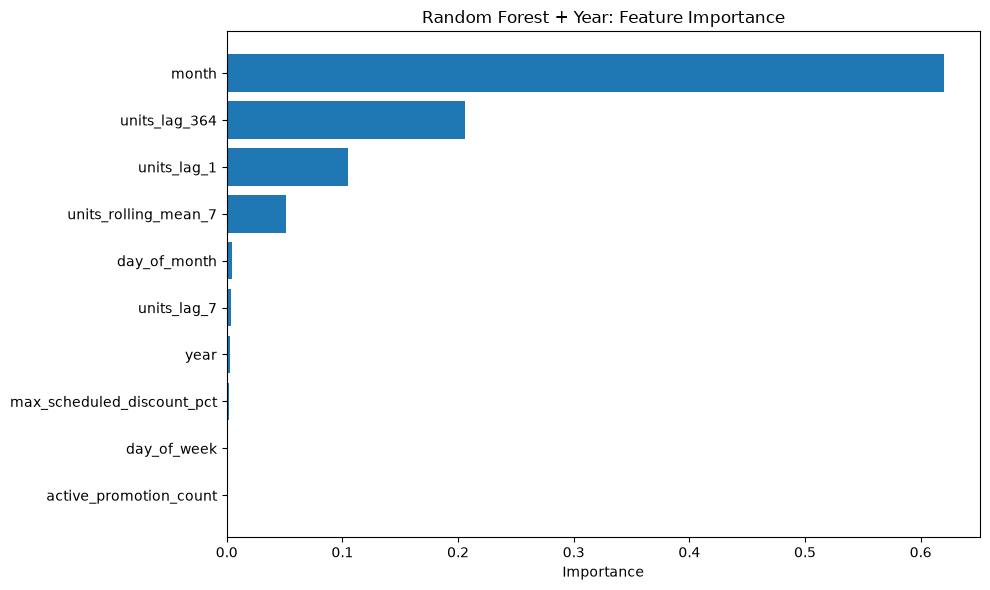

In [84]:
feature_importance_v2 = pd.DataFrame({
    "feature": feature_cols_v2,
    "importance": rf_model_v2.feature_importances_
}).sort_values("importance", ascending=False)

display(feature_importance_v2.round(4))

# Plot the top 10 features
top_features_v2 = (
    feature_importance_v2.head(10)
    .sort_values("importance")
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features_v2["feature"],
    top_features_v2["importance"]
)
plt.title("Random Forest + Year: Feature Importance")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
import pandas as pd

# Historical quarters for rolling-origin evaluation
quarters = [
    ("2024 Q1", "2024-01-01", "2024-03-31"),
    ("2024 Q2", "2024-04-01", "2024-06-30"),
    ("2024 Q3", "2024-07-01", "2024-09-30"),
    ("2024 Q4", "2024-10-01", "2024-12-31"),
    ("2025 Q1", "2025-01-01", "2025-03-31"),
    ("2025 Q2", "2025-04-01", "2025-06-30"),
    ("2025 Q3", "2025-07-01", "2025-09-30"),
]

sales_by_date = daily_clean.set_index("date")["units_sold"]
backtest_results = []

for quarter, start, end in quarters:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)

    train_q = model_data[model_data["date"] < start]
    test_q = model_data[
        (model_data["date"] >= start) &
        (model_data["date"] <= end)
    ]

    model_q = RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    )

    model_q.fit(train_q[feature_cols_v2], train_q["units_sold"])
    predictions = model_q.predict(test_q[feature_cols_v2])
    actual = test_q["units_sold"].to_numpy()

    # Same-date-last-year baseline on the exact same test dates
    baseline = test_q["date"].map(
        lambda d: sales_by_date.get(
            d - pd.DateOffset(years=1), np.nan
        )
    ).to_numpy()

    backtest_results.append({
        "quarter": quarter,
        "days": len(test_q),
        "RF_MAE": mean_absolute_error(actual, predictions),
        "RF_MAPE_pct": np.mean(
            np.abs((actual - predictions) / actual)
        ) * 100,
        "Baseline_MAE": mean_absolute_error(actual, baseline),
        "Baseline_MAPE_pct": np.mean(
            np.abs((actual - baseline) / actual)
        ) * 100
    })

backtest_table = pd.DataFrame(backtest_results)
display(backtest_table.round(2))

,quarter,days,RF_MAE,RF_MAPE_pct,Baseline_MAE,Baseline_MAPE_pct
0,2024 Q1,91,369.08,3.32,520.79,4.60
1,2024 Q2,91,484.75,3.76,705.74,5.52
2,2024 Q3,92,453.10,3.39,704.88,5.41
3,2024 Q4,92,556.83,3.39,824.30,5.19
4,2025 Q1,90,414.14,3.48,709.74,5.90
5,2025 Q2,91,265.12,1.97,670.65,4.97
6,2025 Q3,92,494.50,3.54,699.75,5.07


In [86]:
from pathlib import Path

# Locate the RetailPulse project folder
project_root = Path.cwd()

if project_root.name == "notebooks":
    project_root = project_root.parent

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

# Save the quarterly backtest table
backtest_path = reports_dir / "quarterly_forecast_backtest.csv"
backtest_table.to_csv(backtest_path, index=False)

print("Backtesting results saved to:")
print(backtest_path)

print("\nQuarters evaluated:", len(backtest_table))
print("All quarters show lower RF MAPE:",
      (backtest_table["RF_MAPE_pct"] <
       backtest_table["Baseline_MAPE_pct"]).all())

Backtesting results saved to:
/Users/venumudike/RetailPulse/reports/quarterly_forecast_backtest.csv

Quarters evaluated: 7
All quarters show lower RF MAPE: True


In [87]:
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

reports_dir = project_root / "reports"
reports_dir.mkdir(parents=True, exist_ok=True)

report_path = reports_dir / "forecast_model_evaluation.md"

report_text = """# Demand Forecasting: Model Evaluation

## Objective
Develop a daily retail demand forecasting model for RetailPulse and
compare it against a seasonal-naive baseline using the same calendar
date from the previous year.

## Methodology
A Random Forest Regressor used calendar, historical sales, rolling
average, and scheduled promotion features. Expanding-window,
chronological backtesting covered seven quarters from Q1 2024
through Q3 2025.

## Results
Random Forest had lower MAPE than the seasonal-naive baseline in all
seven evaluated quarters. Mean quarterly MAPE was 3.26% for Random
Forest and 5.24% for the baseline, a relative reduction of about 37.7%.

## Interpretation
The results suggest that historical sales and calendar features
provide useful predictive information. Performance varied by quarter.

## Limitations and Future Work
This was rolling one-day-ahead evaluation, not a fixed-origin,
multi-month forecast. Promotion-feature availability must be verified
for each forecast date. Further validation, leakage checks, and
production monitoring are required.
"""

report_path.write_text(report_text, encoding="utf-8")

print("Report saved to:")
print(report_path)
print("File exists:", report_path.exists())

Report saved to:
/Users/venumudike/RetailPulse/reports/forecast_model_evaluation.md
File exists: True


In [88]:
from pathlib import Path
from joblib import dump
import json
from sklearn.ensemble import RandomForestRegressor

# Locate the RetailPulse project
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

# Train the final model on all available historical data
final_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

final_model.fit(
    model_data[feature_cols_v2],
    model_data["units_sold"]
)

# Save the model
model_path = models_dir / "random_forest_demand_forecast.joblib"
dump(final_model, model_path)

# Save the exact predictor order for future inference
features_path = models_dir / "forecast_features.json"
with open(features_path, "w", encoding="utf-8") as f:
    json.dump(feature_cols_v2, f, indent=2)

print("Final model saved:", model_path)
print("Feature list saved:", features_path)
print("Training rows:", len(model_data))
print("Training date range:",
      model_data["date"].min(), "to", model_data["date"].max())
print("Number of features:", len(feature_cols_v2))

Final model saved: /Users/venumudike/RetailPulse/models/random_forest_demand_forecast.joblib
Feature list saved: /Users/venumudike/RetailPulse/models/forecast_features.json
Training rows: 1097
Training date range: 2022-12-31 00:00:00 to 2025-12-31 00:00:00
Number of features: 14


In [89]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from joblib import load

# Locate the project directory
project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

models_dir = project_root / "models"

# Reload the saved model and feature list
loaded_model = load(
    models_dir / "random_forest_demand_forecast.joblib"
)

with open(
    models_dir / "forecast_features.json",
    "r",
    encoding="utf-8"
) as f:
    loaded_features = json.load(f)

# Prepare one known historical row for a smoke test
sample = model_data[loaded_features].tail(1)

prediction = loaded_model.predict(sample)[0]

print("Model loaded successfully.")
print("Number of features:", len(loaded_features))
print("Input feature count:", sample.shape[1])
print("Sample date:", model_data["date"].iloc[-1])
print("Actual units sold:", model_data["units_sold"].iloc[-1])
print("Sample prediction:", round(prediction, 2))
print("Prediction is finite:", bool(np.isfinite(prediction)))

Model loaded successfully.
Number of features: 14
Input feature count: 14
Sample date: 2025-12-31 00:00:00
Actual units sold: 18180.0
Sample prediction: 18149.07
Prediction is finite: True


In [90]:
import importlib.util
import sys

print("Python executable:", sys.executable)
print("Streamlit installed:", importlib.util.find_spec("streamlit") is not None)

Python executable: /Users/venumudike/RetailPulse/.venv/bin/python
Streamlit installed: False


In [91]:
%pip install streamlit

  Using cached pyarrow-25.0.1-cp311-cp311-macosx_12_0_arm64.whl.metadata (3.0 kB)
  Using cached httptools-0.8.0-cp311-cp311-macosx_11_0_arm64.whl.metadata (3.5 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 841.0 kB/s  0:00:12m0:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.2/797.2 kB 1.3 MB/s  0:00:00m0:00:0100:01
Using cached httptools-0.8.0-cp311-cp311-macosx_11_0_arm64.whl (113 kB)
Using cached pyarrow-25.0.1-cp311-cp311-macosx_12_0_arm64.whl (35.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 993.1 kB/s  0:00:11 eta 0:00:01
Using cached python_multipart-0.0.32-py3-none-any.whl (30 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13/13 [streamlit]13 [streamlit]
Note: you may need to restart the kernel to use updated packages.


In [92]:
import streamlit as st
import sys

print("Streamlit version:", st.__version__)
print("Python executable:", sys.executable)

Streamlit version: 1.64.0
Python executable: /Users/venumudike/RetailPulse/.venv/bin/python
